In [65]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
a = pd.read_csv('data/charge_radii.csv')
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

In [3]:
# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

## Necessary Functions

In [4]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)

In [5]:
def filtered_NZ_extraction(filtered_NZ):
    #We want to create a function that takes only even-even nuclei with N,Z >= 8
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >=8)) & ((isotope[0]%2 == 0) & (isotope[1]%2 == 0)):
            filtered_NZ_new.append(isotope)
    filtered_NZ_new  = np.array(filtered_NZ_new)
    return filtered_NZ_new

def unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ):
    #We want to create a function that extracts nuclei that exist in every models
    for model in models_selected:
        filtered_NZ_new = []
        for isotope in filtered_NZ:
            if ( (isotope[0] == models_data_sets[model]['N']) & (isotope[1] == models_data_sets[model]['Z']) ).any():
                filtered_NZ_new.append(isotope)
        filtered_NZ = np.array(filtered_NZ_new)
    filtered_NZ_df = pd.DataFrame({'N' : filtered_NZ.T[0], 'Z' : filtered_NZ.T[1]})
    return filtered_NZ_new, filtered_NZ_df

def selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, property):
    #We want to create dataframe that contains all the model predictions of a property of interest
    selected_models_data_sets = pd.DataFrame(filtered_NZ_df)
    for model in models_selected:
        merged_df = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), on = ['N', 'Z'], how  = 'inner')
        selected_models_data_sets[model] = merged_df[property]
    return selected_models_data_sets

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets.copy()
    models_output['A'] = models_output['N'] + models_output['Z'] # Put the mass number in our dataframe
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2] # Rearranging columns 
    models_output = models_output[cols]

    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]
    return [models_output, models_output_train, models_output_validation, models_output_test]

def filtered_models_output_extraction(Selected_element, models_output, train_coordinates, validation_coordinates, test_coordinates):
    Z_range = (Selected_element, Selected_element)
    N_range = (0,300)
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output.iloc[train_coordinates][(models_output.iloc[train_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[train_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[train_coordinates]['N'] >= N_range[0]) & (models_output.iloc[train_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output.iloc[validation_coordinates][(models_output.iloc[validation_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[validation_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[validation_coordinates]['N'] >= N_range[0]) & (models_output.iloc[validation_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output.iloc[test_coordinates][(models_output.iloc[test_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[test_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[test_coordinates]['N'] >= N_range[0]) & (models_output.iloc[test_coordinates]['N'] <= N_range[1])]

    return [filtered_models_output, filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test]

def filtered_models_output_stable_extraction(Selected_element, models_output, stable_coordinates):
    Z_range = (Selected_element, Selected_element)
    N_range = (0,300)
    stable_isotopes = []
    for isotope in stable_coordinates:
        if isotope[1] == Selected_element:
            stable_isotopes.append(isotope)
    stable_isotopes = np.array(stable_isotopes)
    
    filtered_models_output_stable = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1])\
                                                 & (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1]) & models_output['N'].isin(stable_isotopes.T[0])]
    return filtered_models_output_stable

def filtered_models_output_dict_extraction(Selected_elements, key_name, models_output, train_coordinates, validation_coordinates, test_coordinates, stable_coordinates):
    filtered_models_output_dict = {}
    for j in Selected_elements:
        key = f"{key_name}" + f"{int(j)}"
        filtered_models_output_dict[key] = filtered_models_output_extraction(int(j), models_output, train_coordinates, validation_coordinates, test_coordinates)
        filtered_models_output_dict[key].append(filtered_models_output_stable_extraction(int(j), models_output, stable_coordinates))
    filtered_models_output_dict.keys()
    return filtered_models_output_dict

def models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output):
    models_PC = {}
    models_PC['N'] = models_output['N']
    models_PC['Z'] = models_output['Z']
    models_PC['A'] = models_output['N'] + models_output['Z']
    models_PC['PC_0'] = predictions_mean

    for i in range(len(Vt_hat)):
        models_PC['PC_' + str(i+1)] = Vt_hat[i].dot(model_predictions.T)
    model_PC = pd.DataFrame(models_PC)
    return model_PC

# Right now there are some more functions that we need for the statistical interference but we did not write it here yet
def USVt_hat_extraction(U,S,Vt, components_kept):
    U_hat = np.array([U.T[i] for i in range(components_kept)]).T
    S_hat = S[:components_kept]
    Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
    return U_hat, S_hat, Vt_hat

def super_params(X,y):
    X_T_X = X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)
    super_param = X_T_X_inv.dot(X.T).dot(y) 
    return super_param

def weights_params_translation(super_params, Vt_hat):
    model_weights = np.dot(super_params, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)
    return model_weights

def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

def supermodel_residuals_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list):
    U_hat, S_hat, Vt_hat = USVt_hat_extraction(U,S,Vt, components_kept) # This gives you the approximation matrix
    # Note that we for any list that we create, we will put full dataset first, and then train, validation, test respectively
    # models_PC_train = models_PC_output(Vt_hat, model_predictions_list[1], predictions_mean) # This gives you the matrix of the PCs
    
    # key_list_PCs=list(models_PC_train.keys()) # columns' names of the PCs matrix

    models_PC_train = models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output)
    X = models_PC_train.values[:,4:]# This is the matrix of the PCs
    # print(X.shape)
    y = models_output['truth'] - predictions_mean
    beta = super_params(X,y) #Calculate the best OLS beta
    model_weights = weights_params_translation(beta, Vt_hat) #Translate from the PCs' params to models' weights
    print(model_weights)

    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = residuals_calculator(model_weights,\
                                                                                                            model_predictions_list, models_output_list)

    return [supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test]

def PC_RMSE_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list):
    # model_predictions and predictions_mean are variables that related to PCA decomposition, and models_output part are related to
    # the part where we want to calculate RMSE
    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = supermodel_residuals_calculator(\
                                                            components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list)
    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )
    print(sigma_train)

    return [sigma_full,sigma_train,sigma_validation,sigma_test]


In [164]:
def plot_model_predictions(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_model_predictions_per_nucleon(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], -filtered_models_output[model]/filtered_models_output['A'],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['truth']/filtered_models_output['A'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['truth']/filtered_models_output['A'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['truth']/filtered_models_output['A'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = -filtered_models_output_stable['truth']/filtered_models_output['A'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = filtered_models_output_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = filtered_models_output_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = filtered_models_output_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = filtered_models_output_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_real_data_dict_per_nucleon(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = -filtered_models_output_dict[dict_keys[i]][1]['truth']/filtered_models_output_dict[dict_keys[i]][1]['A'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = -filtered_models_output_dict[dict_keys[i]][2]['truth']/filtered_models_output_dict[dict_keys[i]][2]['A'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = -filtered_models_output_dict[dict_keys[i]][3]['truth']/filtered_models_output_dict[dict_keys[i]][3]['A'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = -filtered_models_output_dict[dict_keys[i]][4]['truth']/filtered_models_output_dict[dict_keys[i]][4]['A'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_something_else_dict(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], filtered_models_something_else[column], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.show()
    
def plot_filtered_something_else_dict_per_nucleon(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    plot_filtered_real_data_dict_per_nucleon(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], -filtered_models_something_else[column]/filtered_models_something_else_dict[dict_keys[index]][0]['A'], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal BE/A}}$ [MeV]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.show()

# Let'steal this from Pablo like we always do
def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 
    
    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    # plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals # This is when we want to see the actual components of the PCs
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    # plt.show()

### From the new functions that we wrote above, we will need to createa the models_output_list and model_predictions_list. 

In [7]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [8]:
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ)

In [10]:
#Let's create a dataframe that contains all the model predictions
selected_models_data_sets_mass = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'BE')
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'ChRad')

# This dataset does not yet contain the real data, let's now merge this dataset with the real data
truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE[['N', 'Z', 'BE']], on = ['N', 'Z'], how = 'inner') #Add real data to the dataframe
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True) #Rename our truth column
cols_mass = list(selected_models_data_sets_mass.keys())
cols_mass.remove('truth')
cols_mass.insert(2, 'truth') # These 2 lines rearrange the order fo the column
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]

# This is for the radius data
truth_CR_df = a
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, truth_CR_df[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

selected_models_data_sets_mass

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,127.619315,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460
1,10,8,139.807766,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181
2,12,8,151.371414,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242
3,14,8,162.027188,160.513,161.884,163.303,163.311,170.486446,167.278899,166.483309,163.855872,164.192707,157.219361
4,16,8,168.952452,167.472,168.465,170.768,170.970,178.908577,174.420231,173.303716,170.930478,171.196394,163.998623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,1909.066432,1910.765,1907.813,1909.928,1914.193,1894.445901,1900.875946,1898.639172,1902.293050,1907.479821,1908.851310
625,156,106,1923.387483,1925.019,1921.738,1924.361,1928.042,1909.221132,1915.371887,1912.434046,1916.575965,1921.884406,1922.815073
626,156,108,1926.771317,1928.415,1925.436,1927.488,1932.395,1911.680941,1918.341803,1916.133844,1919.723353,1925.454882,1926.206982
627,158,108,1941.337453,1943.010,1939.691,1942.276,1946.498,1927.231556,1933.157370,1930.669126,1934.554087,1940.259078,1940.812152


### We now have 2 separate nuclei set for mass and radii

In [11]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

filtered_NZ_df_mass = selected_models_data_sets_mass[['N', 'Z']]
filtered_NZ_mass = np.array(filtered_NZ_df_mass)
Full_set_mass = filtered_NZ_mass.copy()

### We now need to separate these nuclei to interpolation and extrapolation regions

In [12]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [13]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [14]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

In [15]:
# After having separated our data points into intrapolation and extrapolation part, first we have to extract all the model predictions and perform
# PCA on that data set

In [16]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [17]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [44]:
filtered_models_output_mass_list_50 = filtered_models_output_extraction(50, models_output_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
filtered_models_output_radius_list_20 = filtered_models_output_extraction(20, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

filtered_models_output_mass_stable_50 = filtered_models_output_stable_extraction(50, models_output_mass, stable_coordinates)
filtered_models_output_radius_stable_20 = filtered_models_output_stable_extraction(20, models_output_radius, stable_coordinates_radius)

[filtered_models_output_mass_50, filtered_models_output_mass_train_50, filtered_models_output_mass_validation_50, filtered_models_output_mass_test_50] = filtered_models_output_mass_list_50
[filtered_models_output_radius_50, filtered_models_output_radius_train_20, filtered_models_output_radius_validation_20, filtered_models_output_radius_test_20] = filtered_models_output_radius_list_20

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values
model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))
model_predictions_combined_list = [model_predictions_combined, model_predictions_combined_train, model_predictions_combined_validation, model_predictions_combined_test]

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

predictions_mean_mass_df = pd.DataFrame({'N' : filtered_NZ_mass.T[0], 'Z' : filtered_NZ_mass.T[1], 'A' : filtered_NZ_mass.T[0] + filtered_NZ_mass.T[1], 'PC_0' : predictions_mean_mass})

In [20]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(167,1)
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(334,1)
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

if centering_data:
    model_predictions_mass_validation_processed = model_predictions_mass_validation - predictions_mean_mass_validation[:,None]
    model_predictions_mass_test_processed = model_predictions_mass_test - predictions_mean_mass_test[:,None]
    model_predictions_mass_processed = model_predictions_mass - predictions_mean_mass[:,None]

### Some of the few cells below will help us visualize if our data is correlated or not

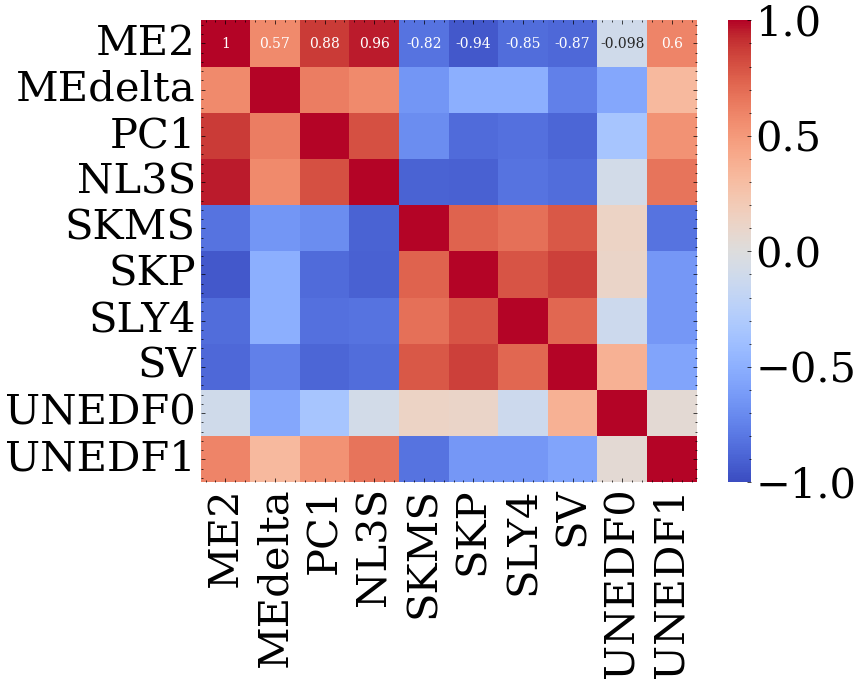

In [73]:
plt.figure(figsize=(8,6))

Pearson_corr_matrix = (models_output_mass_train[models_selected] - predictions_mean_mass_train[:, None]).corr(method='pearson')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
sns.heatmap(Pearson_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig('Plots/Radii data/Pearson corr matrix comparison/Pearson matrix - mass data')
plt.show()

In [69]:
Pearson_corr_matrix

,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
ME2,1.000000,0.571371,0.880688,0.955438,-0.819615,-0.941951,-0.848919,-0.873558,-0.097939,0.600050
MEdelta,0.571371,1.000000,0.629358,0.577261,-0.642681,-0.507528,-0.506327,-0.756436,-0.554545,0.321059
PC1,0.880688,0.629358,1.000000,0.809157,-0.689673,-0.853535,-0.830314,-0.879533,-0.344796,0.538939
NL3S,0.955438,0.577261,0.809157,1.000000,-0.892045,-0.899688,-0.818003,-0.849952,-0.080704,0.667362
SKMS,-0.819615,-0.642681,-0.689673,-0.892045,1.000000,0.740616,0.685265,0.778703,0.125588,-0.814972
SKP,-0.941951,-0.507528,-0.853535,-0.899688,0.740616,1.000000,0.789857,0.861188,0.113524,-0.633091
SLY4,-0.848919,-0.506327,-0.830314,-0.818003,0.685265,0.789857,1.000000,0.720221,-0.117510,-0.640133
SV,-0.873558,-0.756436,-0.879533,-0.849952,0.778703,0.861188,0.720221,1.000000,0.373458,-0.563401
UNEDF0,-0.097939,-0.554545,-0.344796,-0.080704,0.125588,0.113524,-0.117510,0.373458,1.000000,0.054314
UNEDF1,0.600050,0.321059,0.538939,0.667362,-0.814972,-0.633091,-0.640133,-0.563401,0.054314,1.000000


In [71]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(model_predictions_mass_train_processed.T)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[7.03419259e-01 1.28241161e-01 6.56135798e-02 4.92807199e-02
 2.30377866e-02 2.03012622e-02 6.39739956e-03 2.87264057e-03
 8.36190915e-04 1.14116960e-32]


[1.01616287e+02 4.33880285e+01 3.10350938e+01 2.68964349e+01
 1.83897816e+01 1.72630575e+01 9.69076214e+00 6.49376909e+00
 3.50355483e+00 5.94883490e-12]


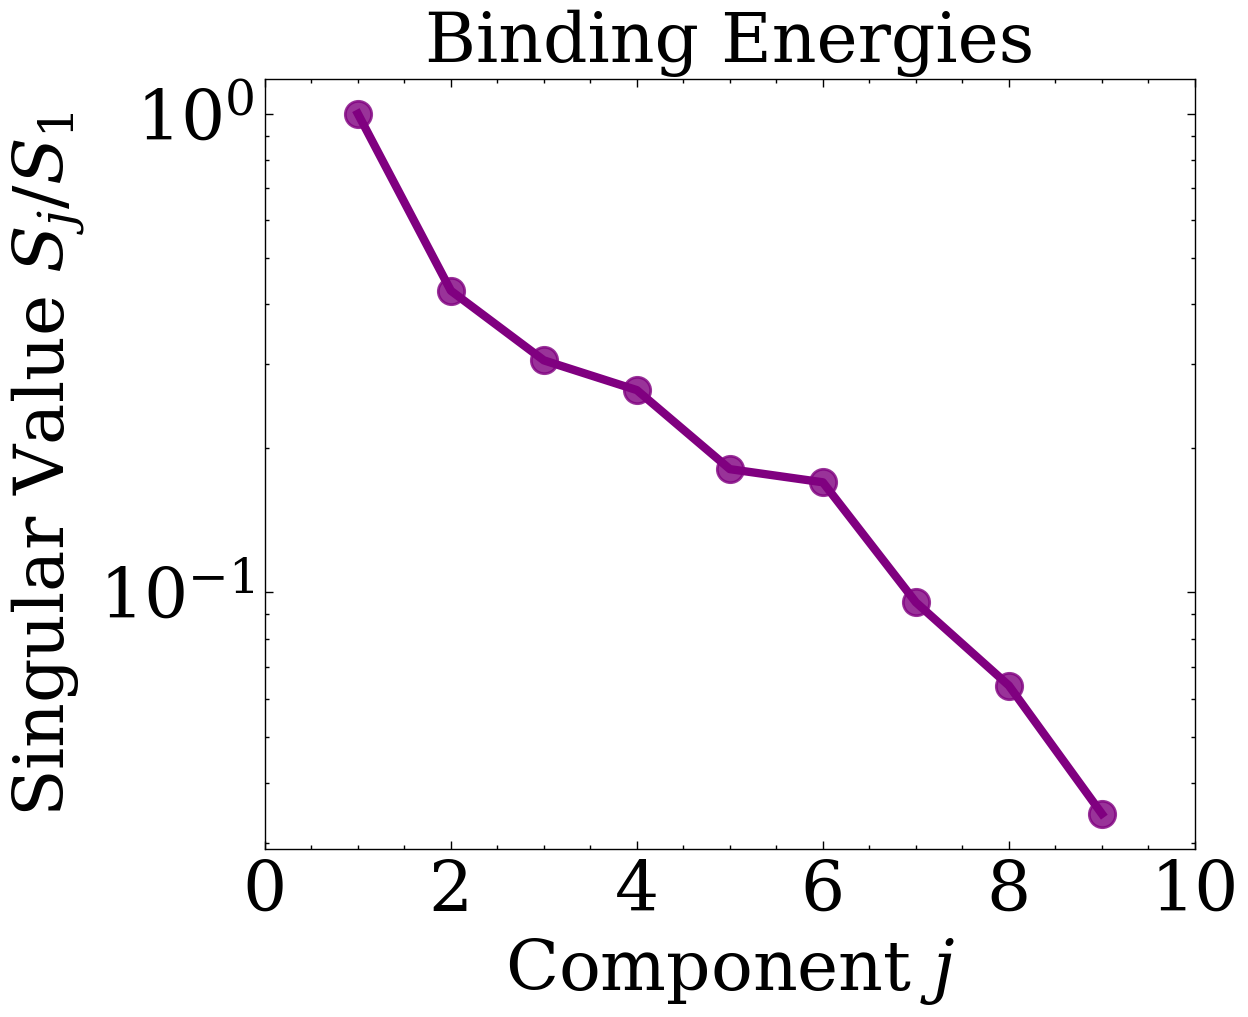

In [22]:
U, S, Vt = np.linalg.svd(model_predictions_mass_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Binding Energies', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Singular Values/Singular Values - Radius Calibration.png')
plt.show()

In [23]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [24]:
models_PC_mass = models_PC_output(Vt_hat, model_predictions_mass, predictions_mean_mass, models_output_mass)
models_PC_mass_train = models_PC_output(Vt_hat, model_predictions_mass_train, predictions_mean_mass_train, models_output_mass_train)
models_PC_mass_validation = models_PC_output(Vt_hat, model_predictions_mass_validation, predictions_mean_mass_validation, models_output_mass_validation)
models_PC_mass_test = models_PC_output(Vt_hat, model_predictions_mass_test, predictions_mean_mass_test, models_output_mass_test)

In [26]:
models_PC_mass_train

,N,Z,A,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,8,8,16,127.471605,-0.034962,-0.027119,0.053964,0.134900,0.101676,-0.205094,0.047272,0.095032,0.124108
1,10,8,18,141.937856,-0.056097,0.012806,0.048081,0.103282,0.098885,-0.200883,0.081550,0.131099,0.081171
2,12,8,20,153.795002,-0.071713,0.038960,0.077767,0.085796,0.103551,-0.183648,0.117793,0.245898,0.048242
6,8,10,18,134.555183,-0.060155,0.032535,0.027953,0.065835,0.093896,-0.201646,0.040258,0.151780,0.104047
7,10,10,20,157.290193,-0.051110,0.026909,0.020446,0.082932,0.026283,-0.175519,-0.048974,0.017619,0.054559
...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,144,92,236,1786.600059,0.095031,0.051666,0.055681,-0.066573,-0.078432,-0.054461,-0.011746,-0.037899,-0.031898
584,146,92,238,1797.703324,0.090908,0.064495,0.079339,-0.067967,-0.103457,-0.045858,-0.010303,-0.020487,0.001991
585,148,92,240,1808.256735,0.090575,0.071956,0.109146,-0.060810,-0.126505,-0.037467,-0.009566,-0.027350,0.007595
590,142,94,236,1784.836690,0.124547,0.017113,0.016449,-0.066441,0.010212,-0.084397,0.018082,-0.062272,-0.131297


## Let's  now make the graph of the RMSE as the number of PCs increase

In [27]:
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_mass_train, predictions_mean_mass_train, models_output_mass_train, models_output_radius_list, model_predictions_radius_list)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[ 0.14268546  0.13148597  0.17906508  0.1769355  -0.02392334  0.04781409
  0.00407381  0.06491235  0.11454135  0.16240972]
0.01946143105393456
[-0.03700763 -0.01025825  0.35976009  0.07885952  0.01299534  0.16062085
 -0.07265435 -0.02315701  0.33267095  0.19817049]
0.01923019086097007
[-0.02149215 -0.00766472  0.37656558  0.08438254  0.05134307  0.14413249
 -0.10435511 -0.02470667  0.33033944  0.17145553]
0.018968917136828085
[ 0.02303077 -0.10898184  0.28535797  0.11307275  0.07202506  0.10663936
 -0.14593911  0.02437403  0.4012503   0.22917071]
0.018946518659734658
[-0.01592104  0.02712739  0.20001942  0.02216797  0.09667775  0.19880266
 -0.30845962  0.0772458   0.38538042  0.31695925]
0.020237867805465874
[-0.0076574   0.07176247  0.13549172  0.07925126  0.03078375  0.2675717
 -0.32827379  0.08258988  0.4945345   0.17394592]
0.020350567332221785
[-0.07968879  0.33395006  0.04236577 -0.03674374  0.10118437 -0.07933093
 -0.20886678 -0.07374544  0.76712379  0.23375169]
0.02446210018019

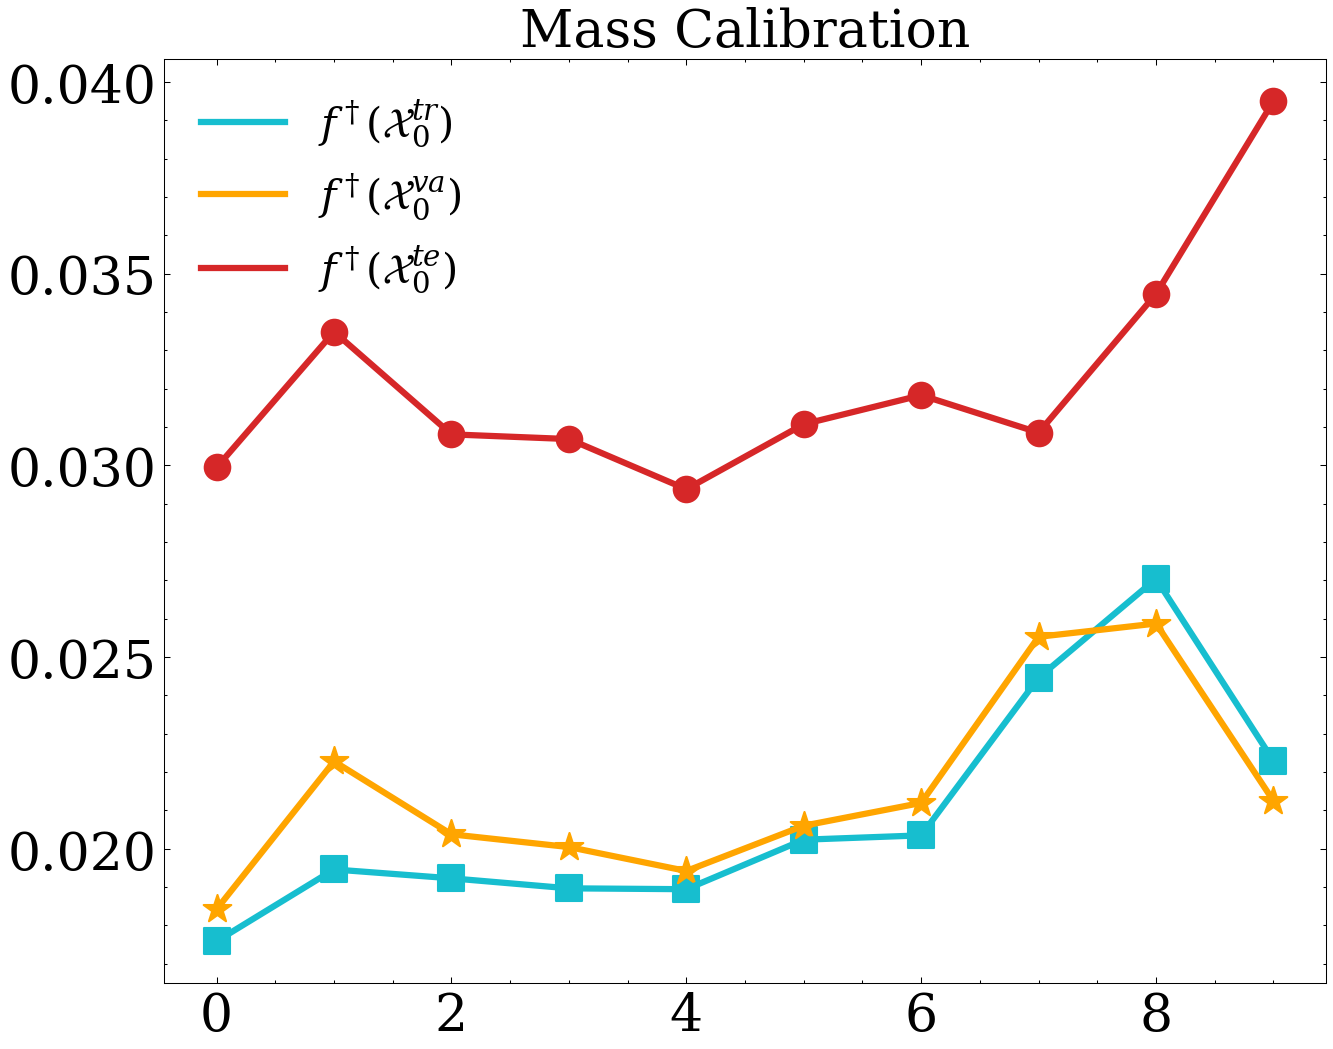

In [28]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Mass Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Radius Analysis.png')
# plt.legend(fontsize=30)
plt.show()

In [29]:
if centering_data:
    s_mass_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_mass_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_mass_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_mass_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_mass_train, predictions_mean_mass_train, models_output_mass_train, models_output_mass_list, model_predictions_mass_list)
        s_mass_all.append(res[0])
        s_mass_train.append(res[1])
        s_mass_validation.append(res[2])
        s_mass_test.append(res[3])

[ 0.14268546  0.13148597  0.17906508  0.1769355  -0.02392334  0.04781409
  0.00407381  0.06491235  0.11454135  0.16240972]
1.537880816378453
[-0.03700763 -0.01025825  0.35976009  0.07885952  0.01299534  0.16062085
 -0.07265435 -0.02315701  0.33267095  0.19817049]
1.136012074081781
[-0.02149215 -0.00766472  0.37656558  0.08438254  0.05134307  0.14413249
 -0.10435511 -0.02470667  0.33033944  0.17145553]
1.1303039938526862
[ 0.02303077 -0.10898184  0.28535797  0.11307275  0.07202506  0.10663936
 -0.14593911  0.02437403  0.4012503   0.22917071]
1.0915361225137998
[-0.01592104  0.02712739  0.20001942  0.02216797  0.09667775  0.19880266
 -0.30845962  0.0772458   0.38538042  0.31695925]
1.0484150012425193
[-0.0076574   0.07176247  0.13549172  0.07925126  0.03078375  0.2675717
 -0.32827379  0.08258988  0.4945345   0.17394592]
1.023802401644926
[-0.07968879  0.33395006  0.04236577 -0.03674374  0.10118437 -0.07933093
 -0.20886678 -0.07374544  0.76712379  0.23375169]
0.970765198253116
[-0.5034078

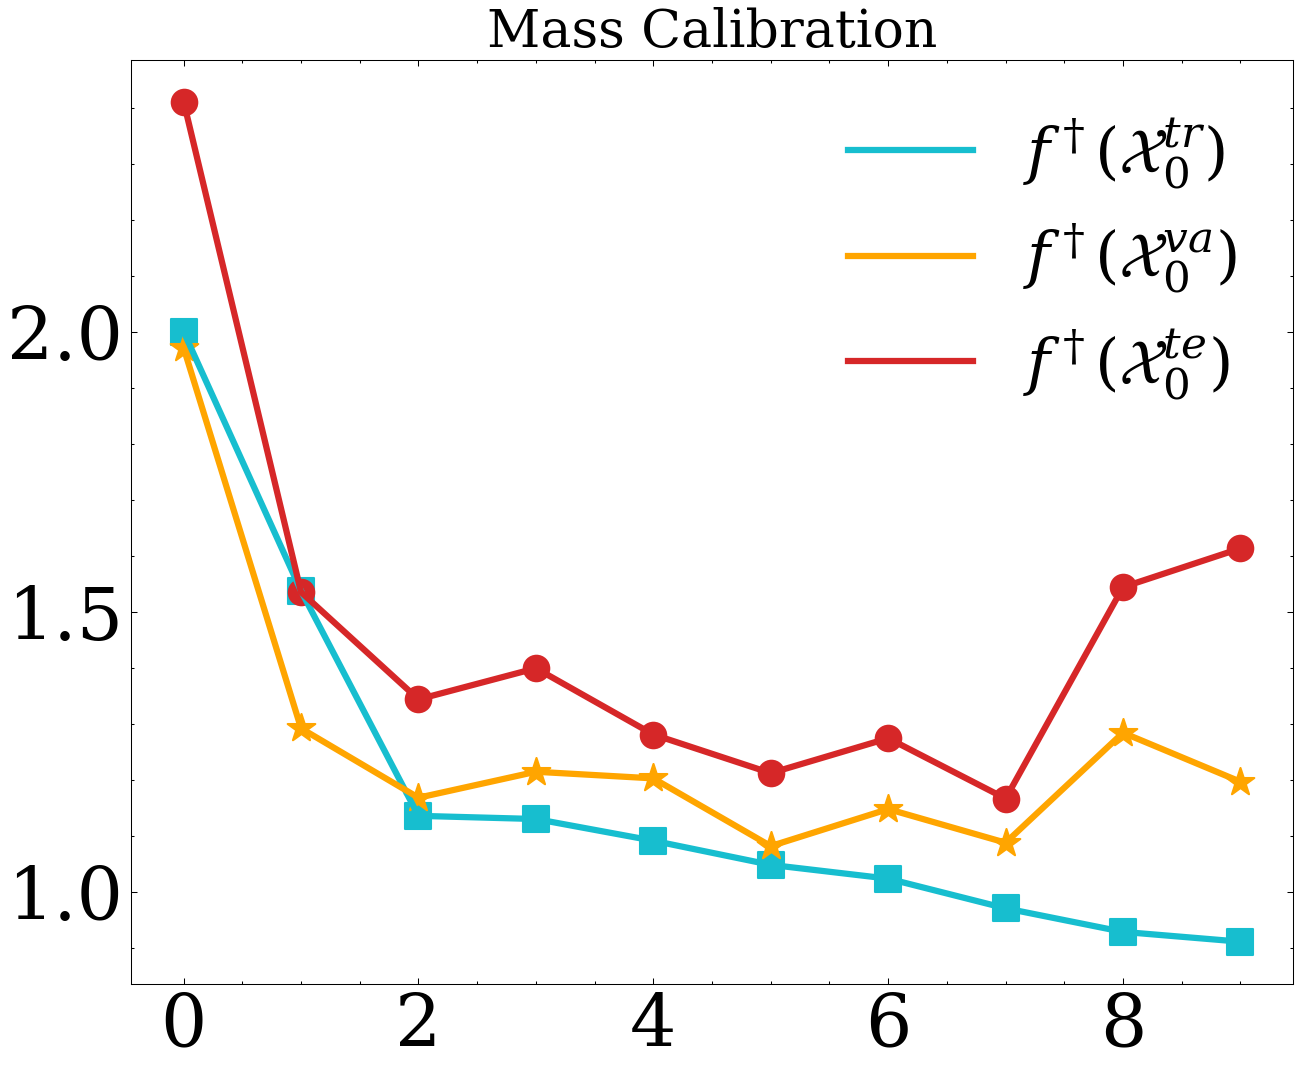

In [30]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Mass Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Mass RMSE decay - Radius Analysis.png')
plt.legend(fontsize=30)
plt.show()

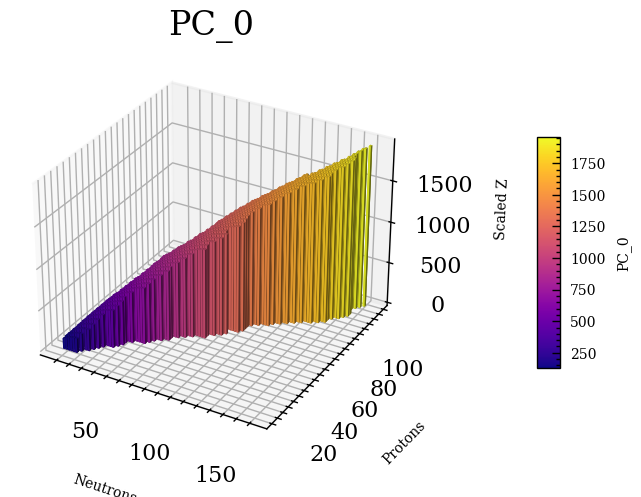

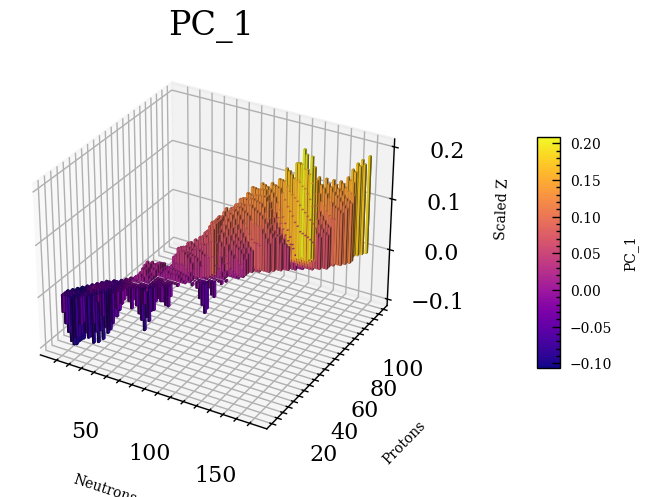

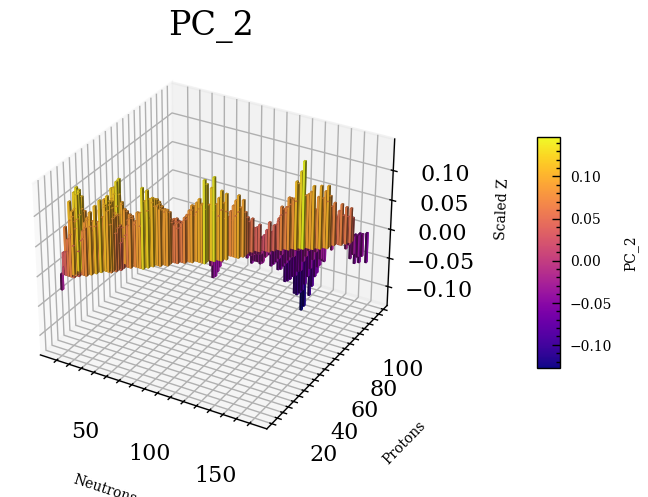

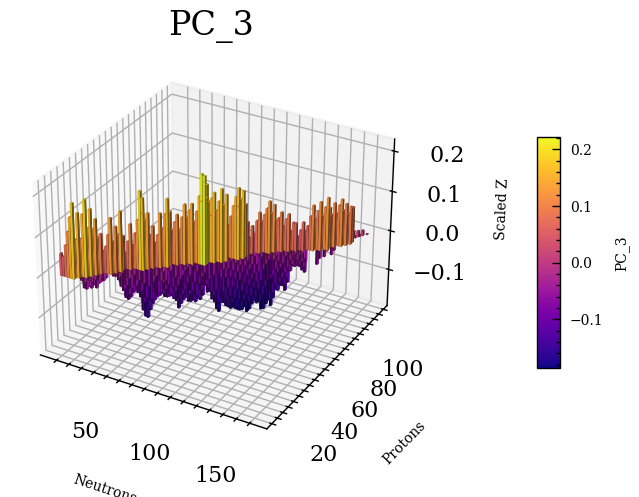

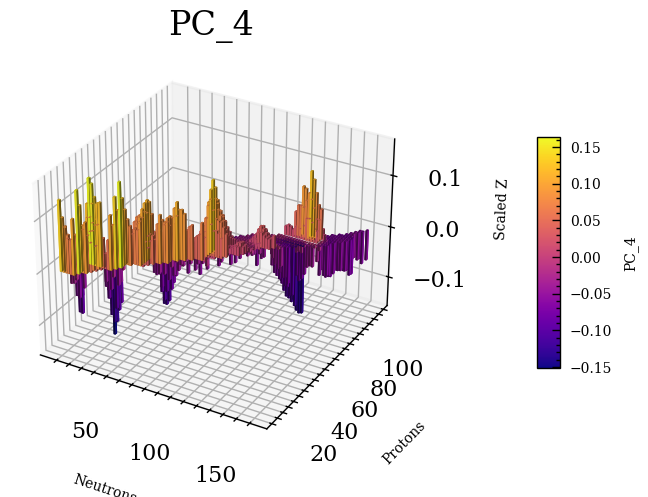

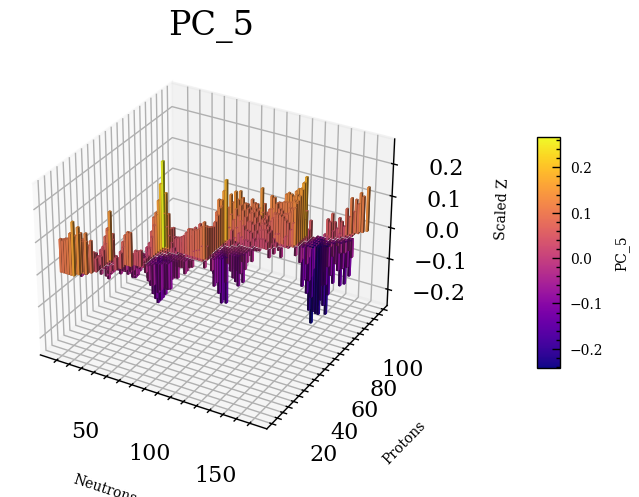

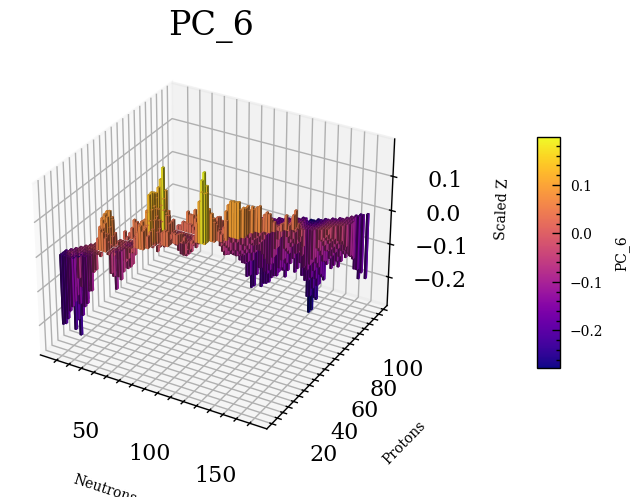

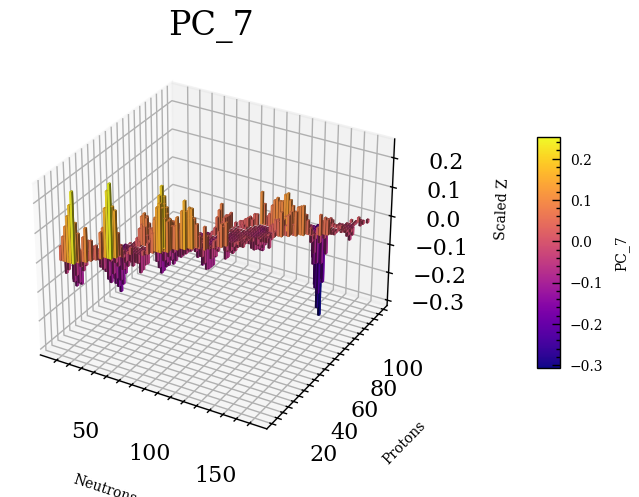

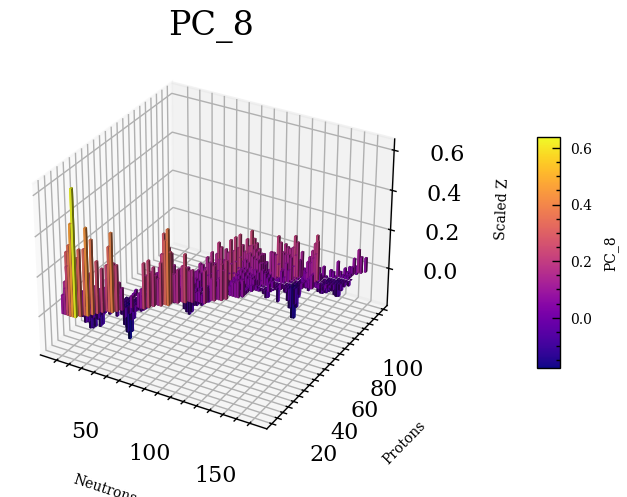

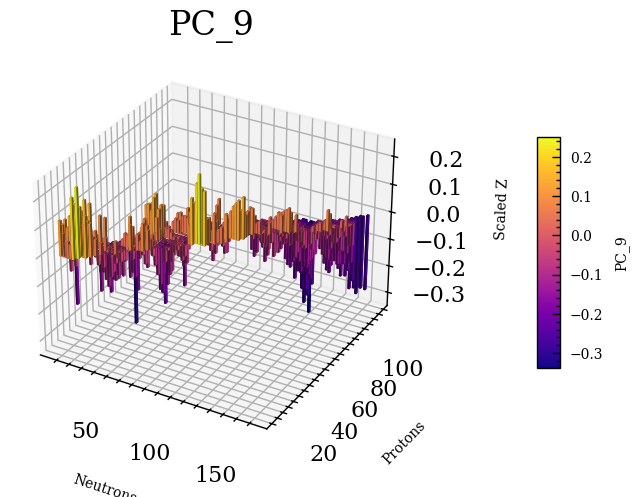

In [165]:
# This is the 3D visualization of the principal components
for PC in list(models_PC_mass.keys())[3:]:
    plot_heatmap_3D(filtered_NZ_df_mass['N'], filtered_NZ_df_mass['Z'], models_PC_mass[PC], PC, elev=30,azim=-60)
    plt.savefig(f'Plots/Radii Data/PCs 3D heat map - Mass/{PC}')

In [33]:
#Let's now graph the mean model predictions for different isotopes 

In [34]:
x = np.linspace(20,90,8)

In [45]:
filtered_predictions_mean_mass_dict= filtered_models_output_dict_extraction(x, 'filtered_predictions_mean_mass_list_' , predictions_mean_mass_df,\
                                    train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass, stable_coordinates)
filtered_predictions_mean_mass_dict.keys()

dict_keys(['filtered_predictions_mean_mass_list_20', 'filtered_predictions_mean_mass_list_30', 'filtered_predictions_mean_mass_list_40', 'filtered_predictions_mean_mass_list_50', 'filtered_predictions_mean_mass_list_60', 'filtered_predictions_mean_mass_list_70', 'filtered_predictions_mean_mass_list_80', 'filtered_predictions_mean_mass_list_90'])

In [46]:
filtered_models_output_mass_dict = filtered_models_output_dict_extraction(x, 'filtered_models_output_mass_list_' , models_output_mass,\
                                    train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass, stable_coordinates)
filtered_models_output_mass_dict.keys()

dict_keys(['filtered_models_output_mass_list_20', 'filtered_models_output_mass_list_30', 'filtered_models_output_mass_list_40', 'filtered_models_output_mass_list_50', 'filtered_models_output_mass_list_60', 'filtered_models_output_mass_list_70', 'filtered_models_output_mass_list_80', 'filtered_models_output_mass_list_90'])

In [47]:
filtered_predictions_mean_mass_dict[key][0]

,N,Z,A,PC_0
49,16,20,36,283.504973
50,18,20,38,314.778400
51,20,20,40,342.792610
52,22,20,42,363.954405
53,24,20,44,382.963640
54,26,20,46,400.585830
55,28,20,48,416.383128
56,30,20,50,428.673536
57,32,20,52,438.909323
58,34,20,54,446.907118


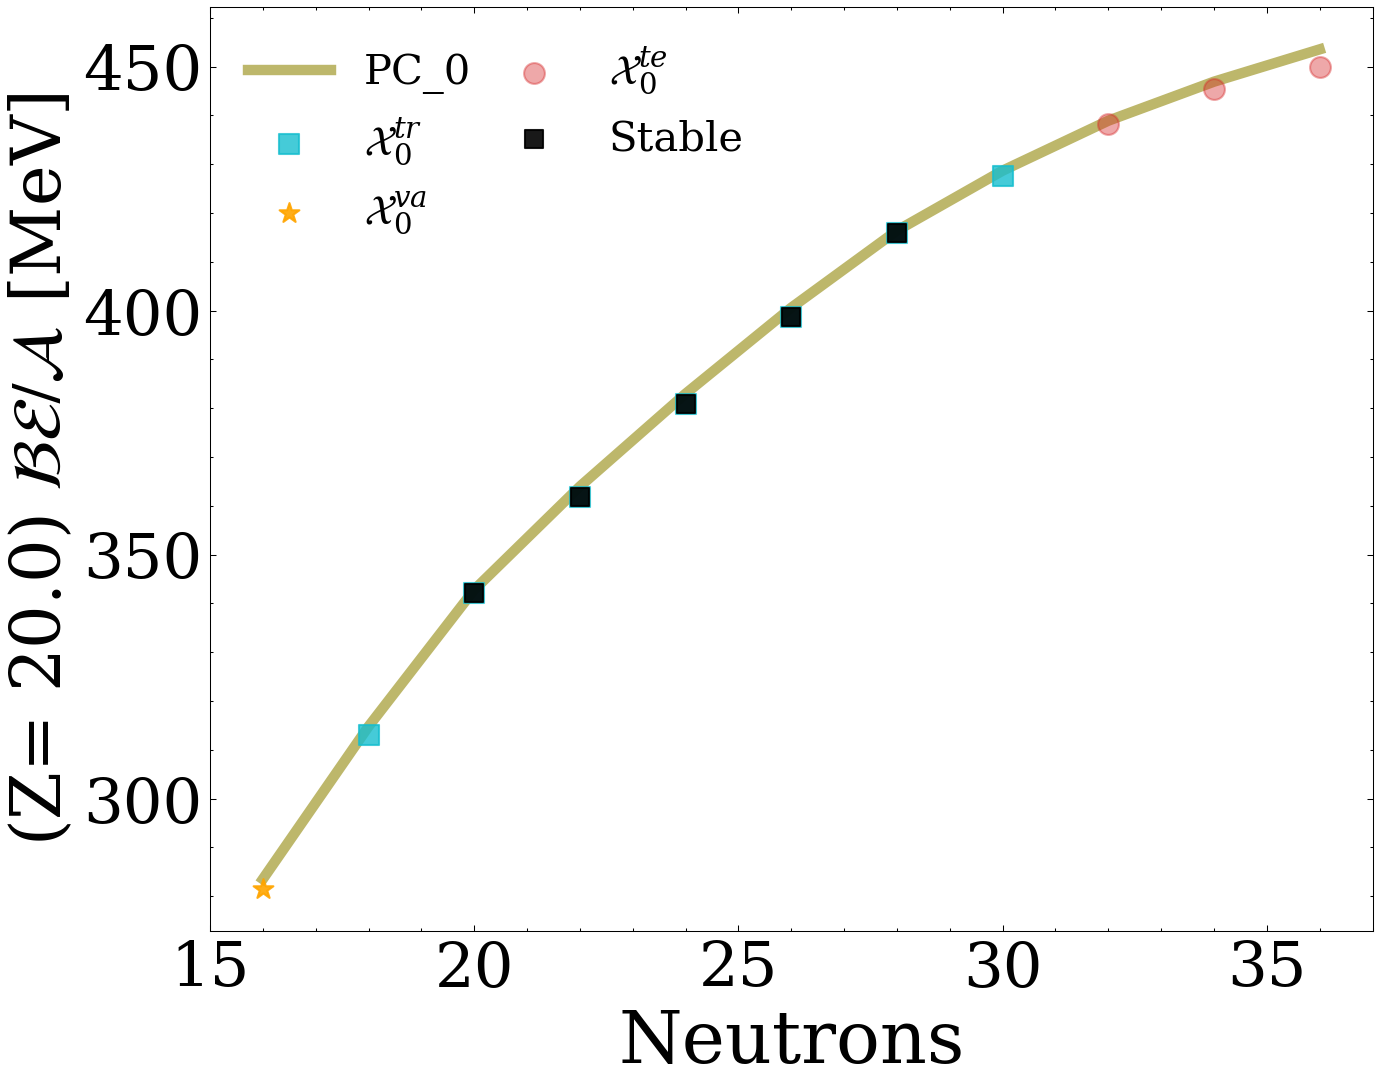

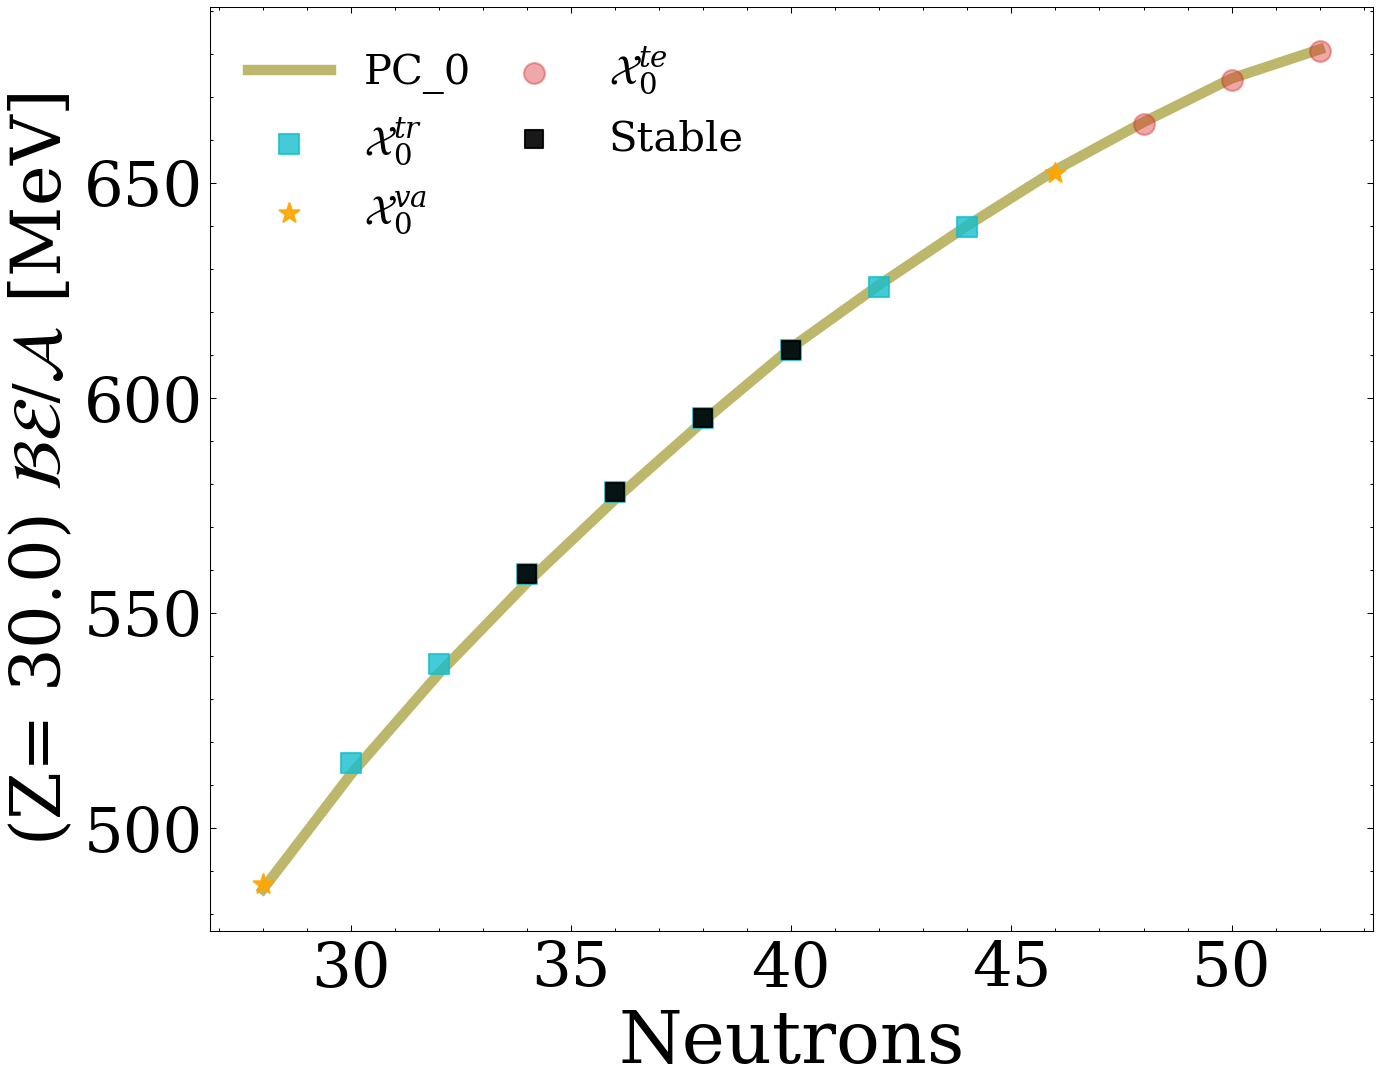

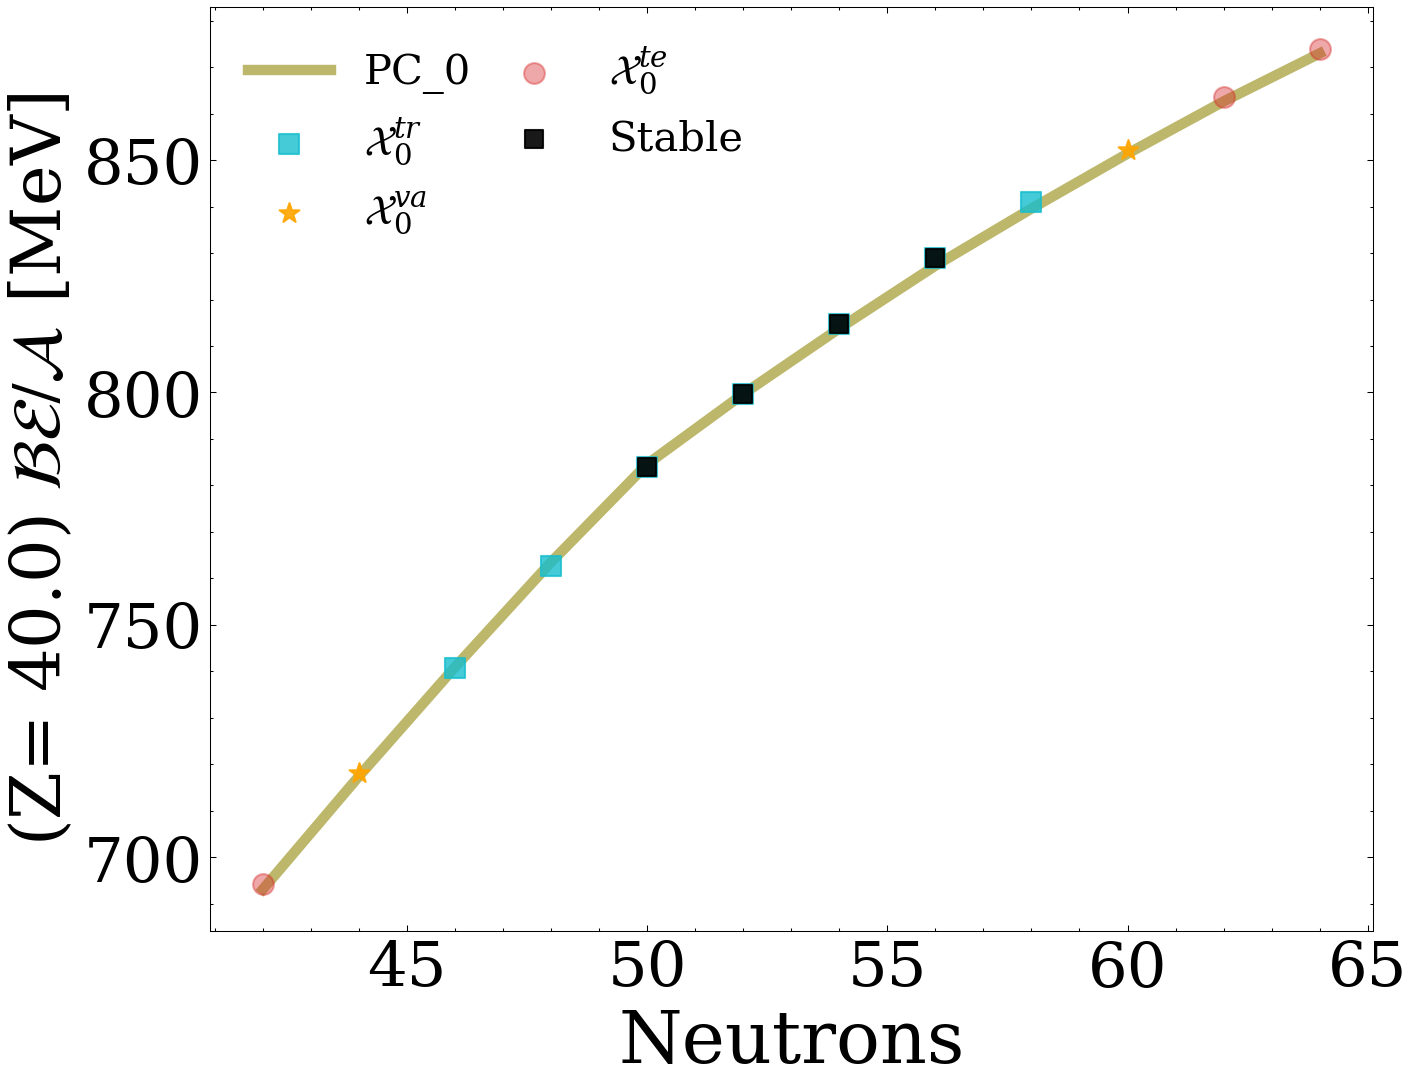

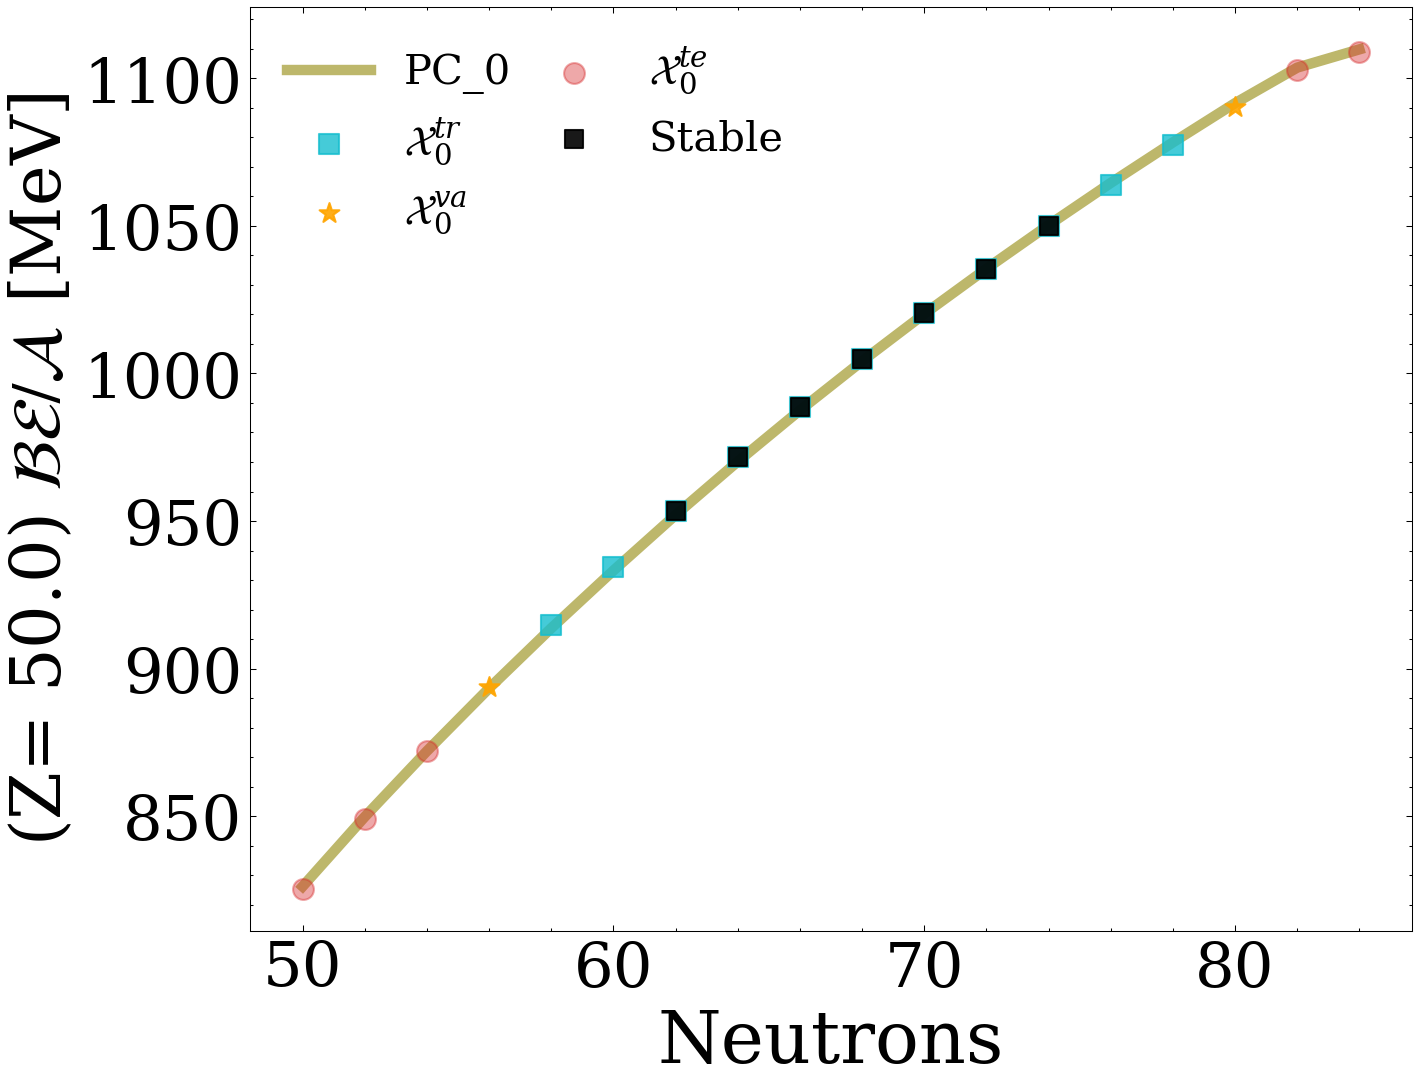

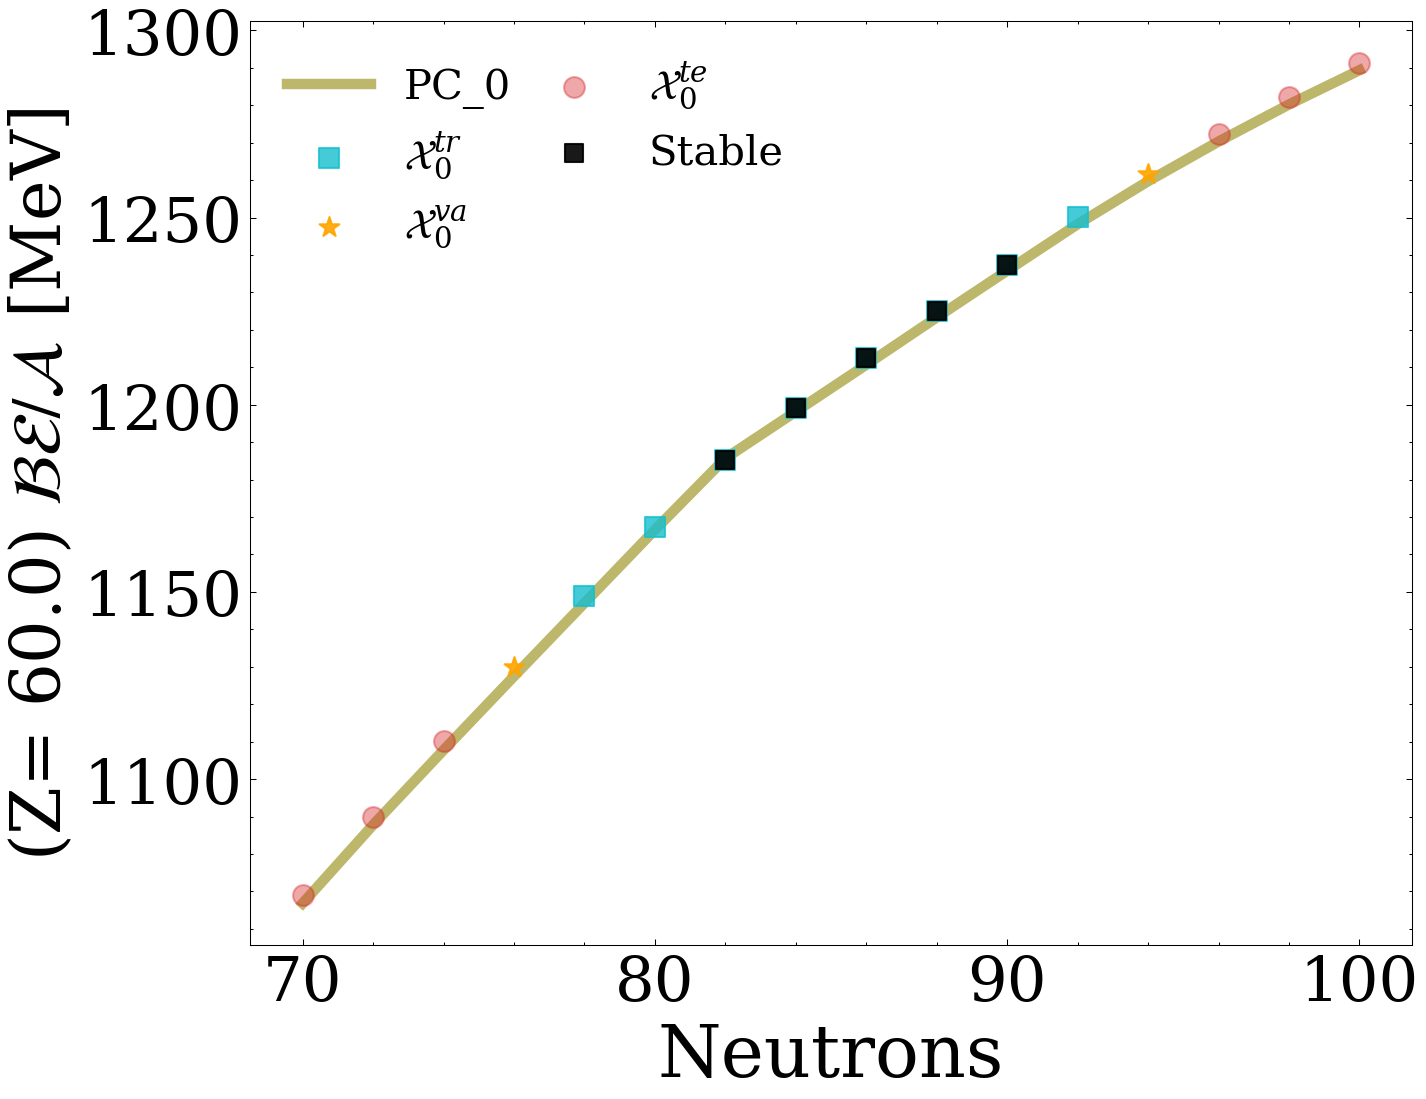

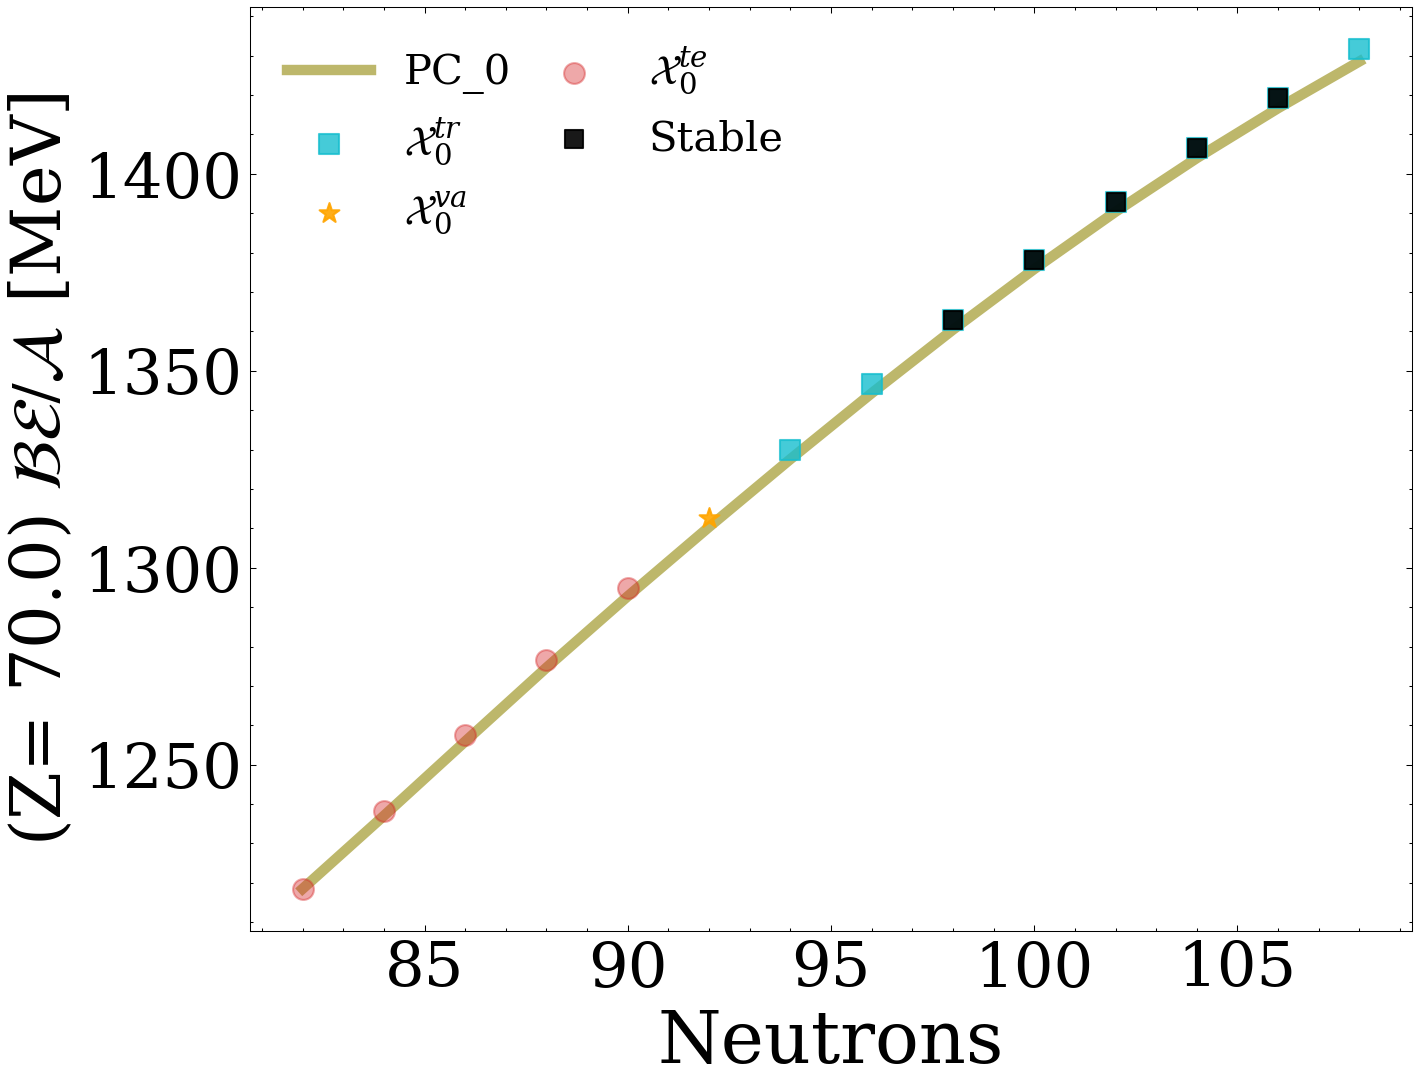

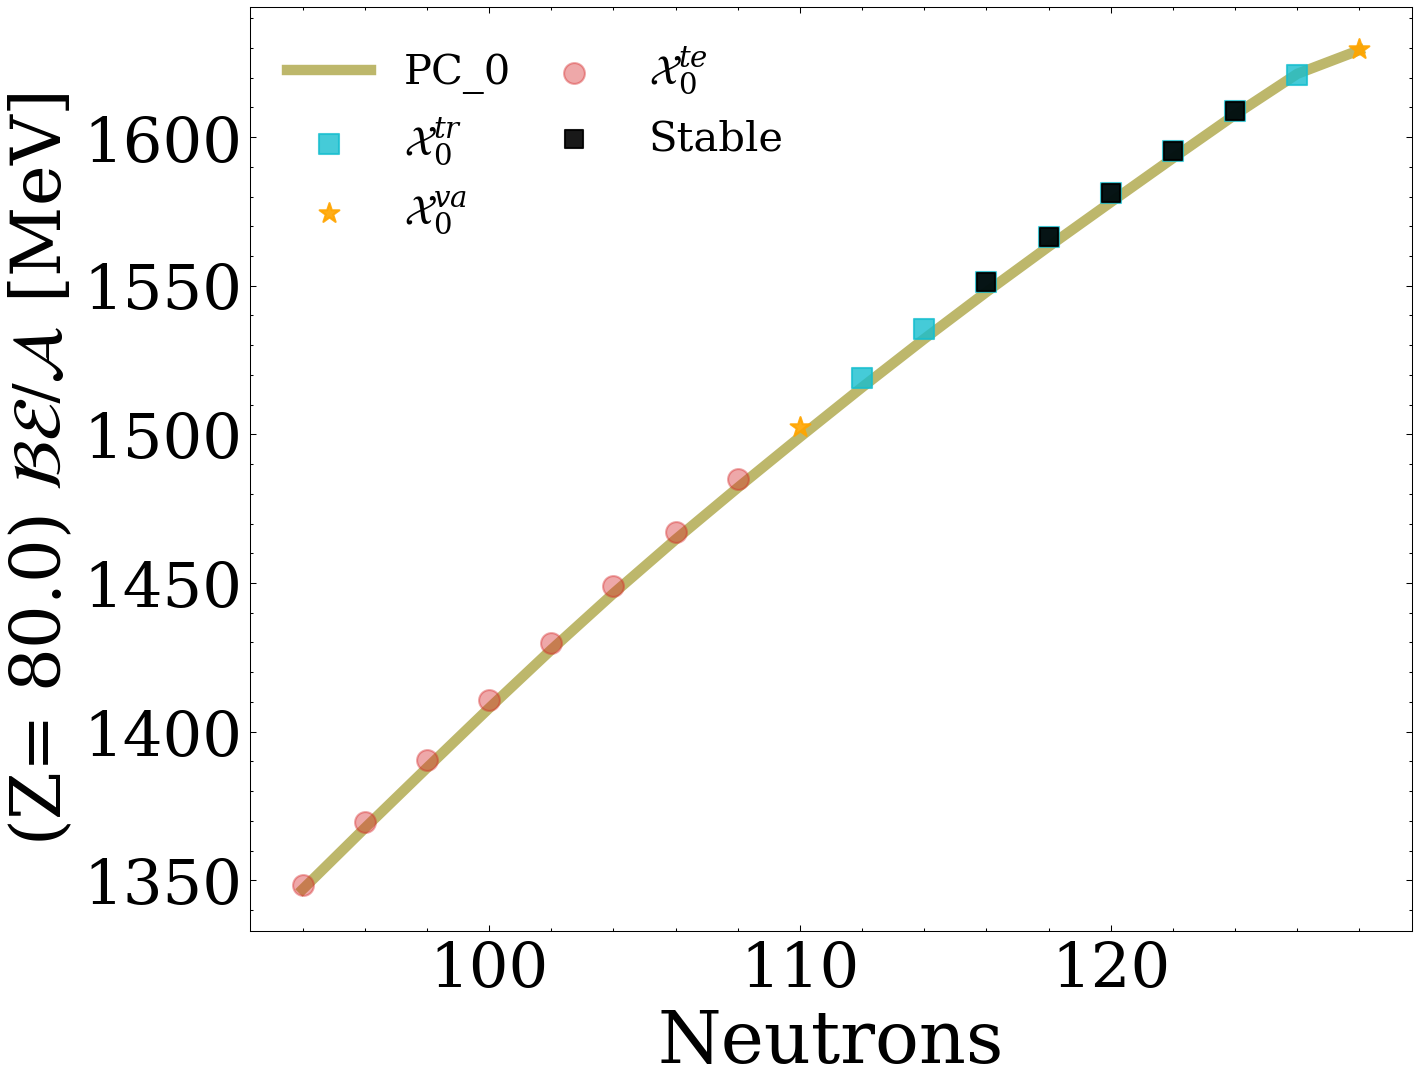

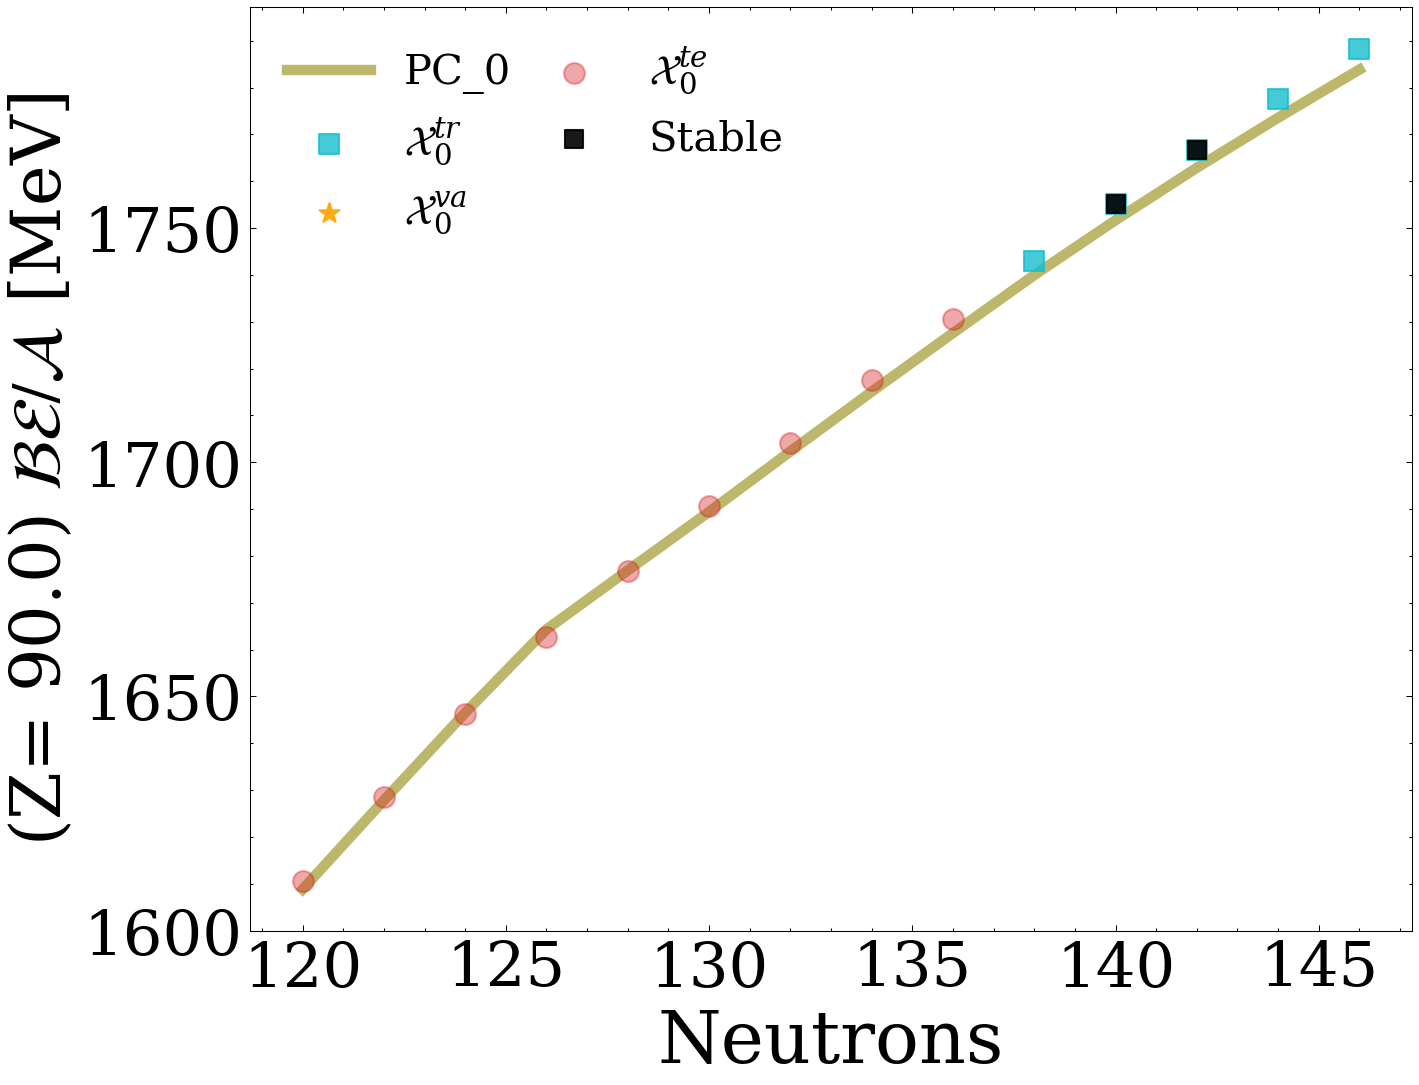

In [202]:
Selected_elements_list = ['Ca', 'Zn', 'Zr', 'Sn', 'Nd', 'Yb', 'Hg', 'Th']
dict_keys_mean = list(filtered_predictions_mean_mass_dict.keys())
dict_keys = list(filtered_models_output_mass_dict.keys())

i = 0
for key in dict_keys_mean:
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose
    plt.plot(filtered_predictions_mean_mass_dict[key][0]["N"], filtered_predictions_mean_mass_dict[key][0]['PC_0'] , color="darkkhaki", label='PC_0',linewidth=5)

    color_local= "khaki"

    # This gives you training predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][1]["N"], y = filtered_models_output_mass_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][2]["N"], y = filtered_models_output_mass_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][3]["N"], y = filtered_models_output_mass_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][4]["N"], y = filtered_models_output_mass_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {x[i]}) $ {{\\cal BE/A}}$ [MeV]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.show()

    i = i+1

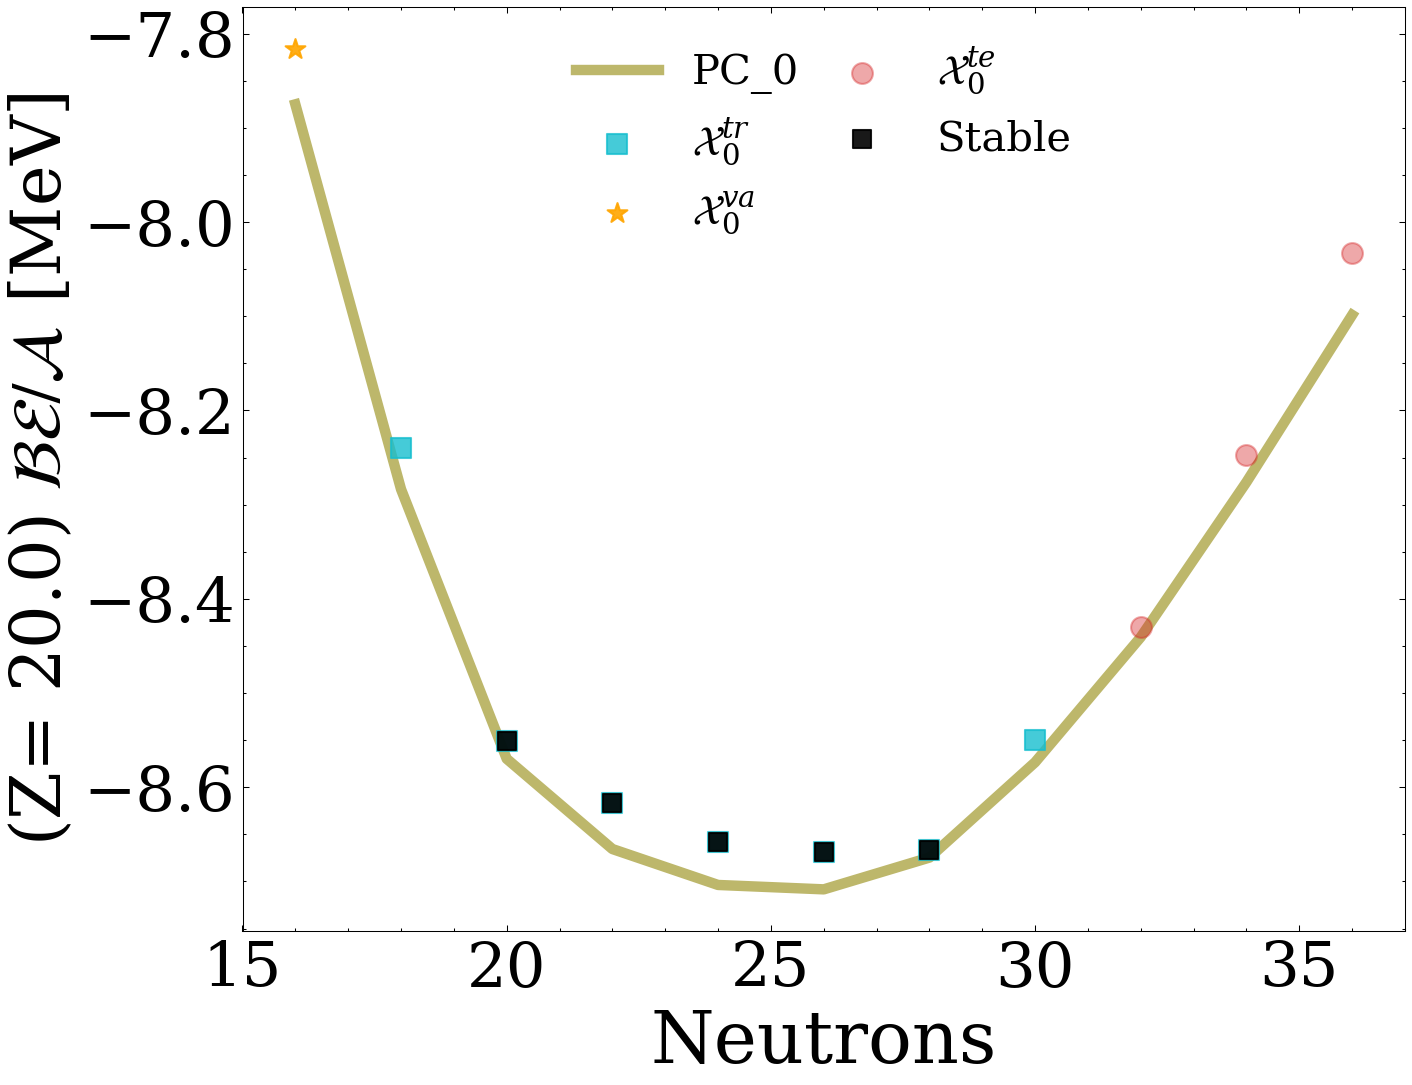

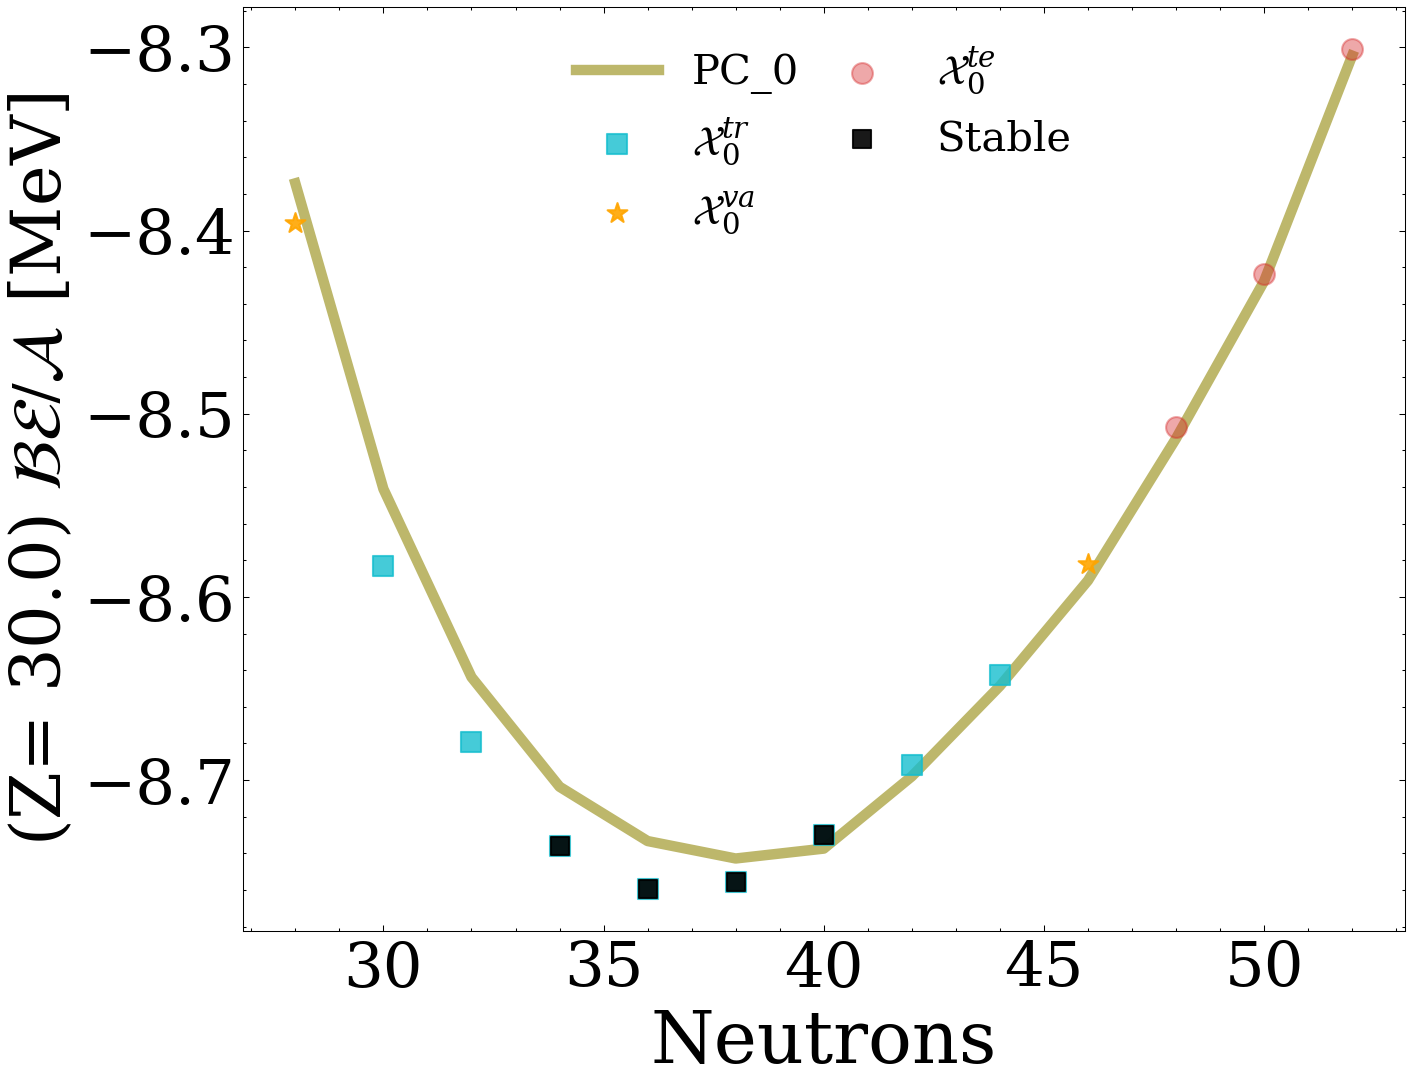

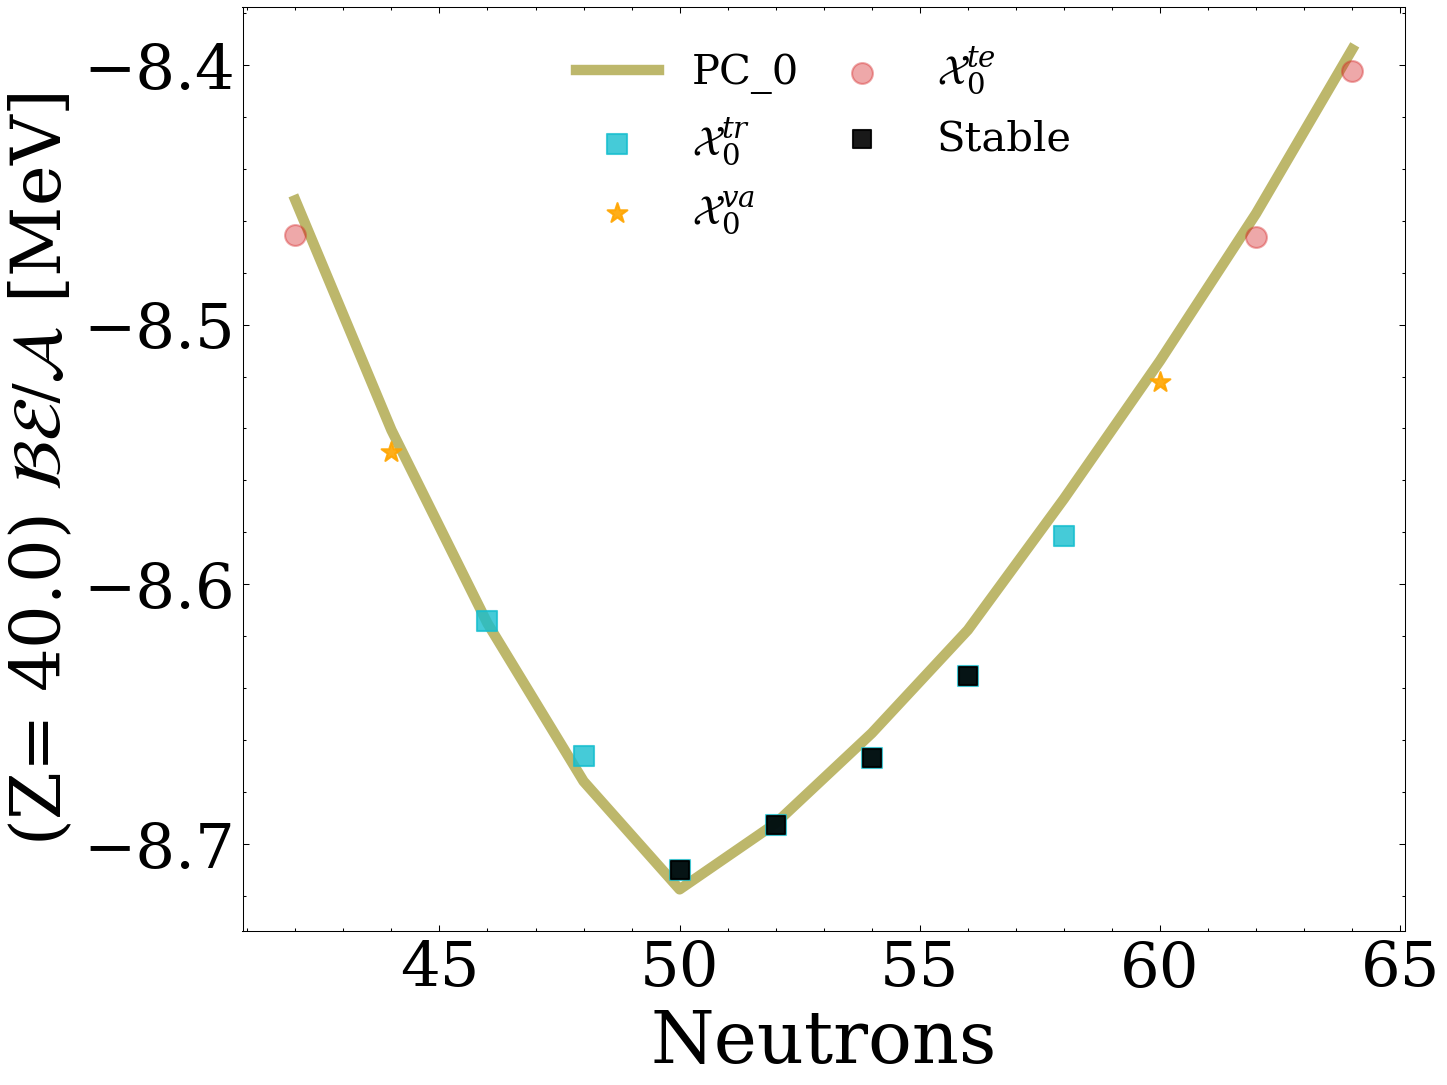

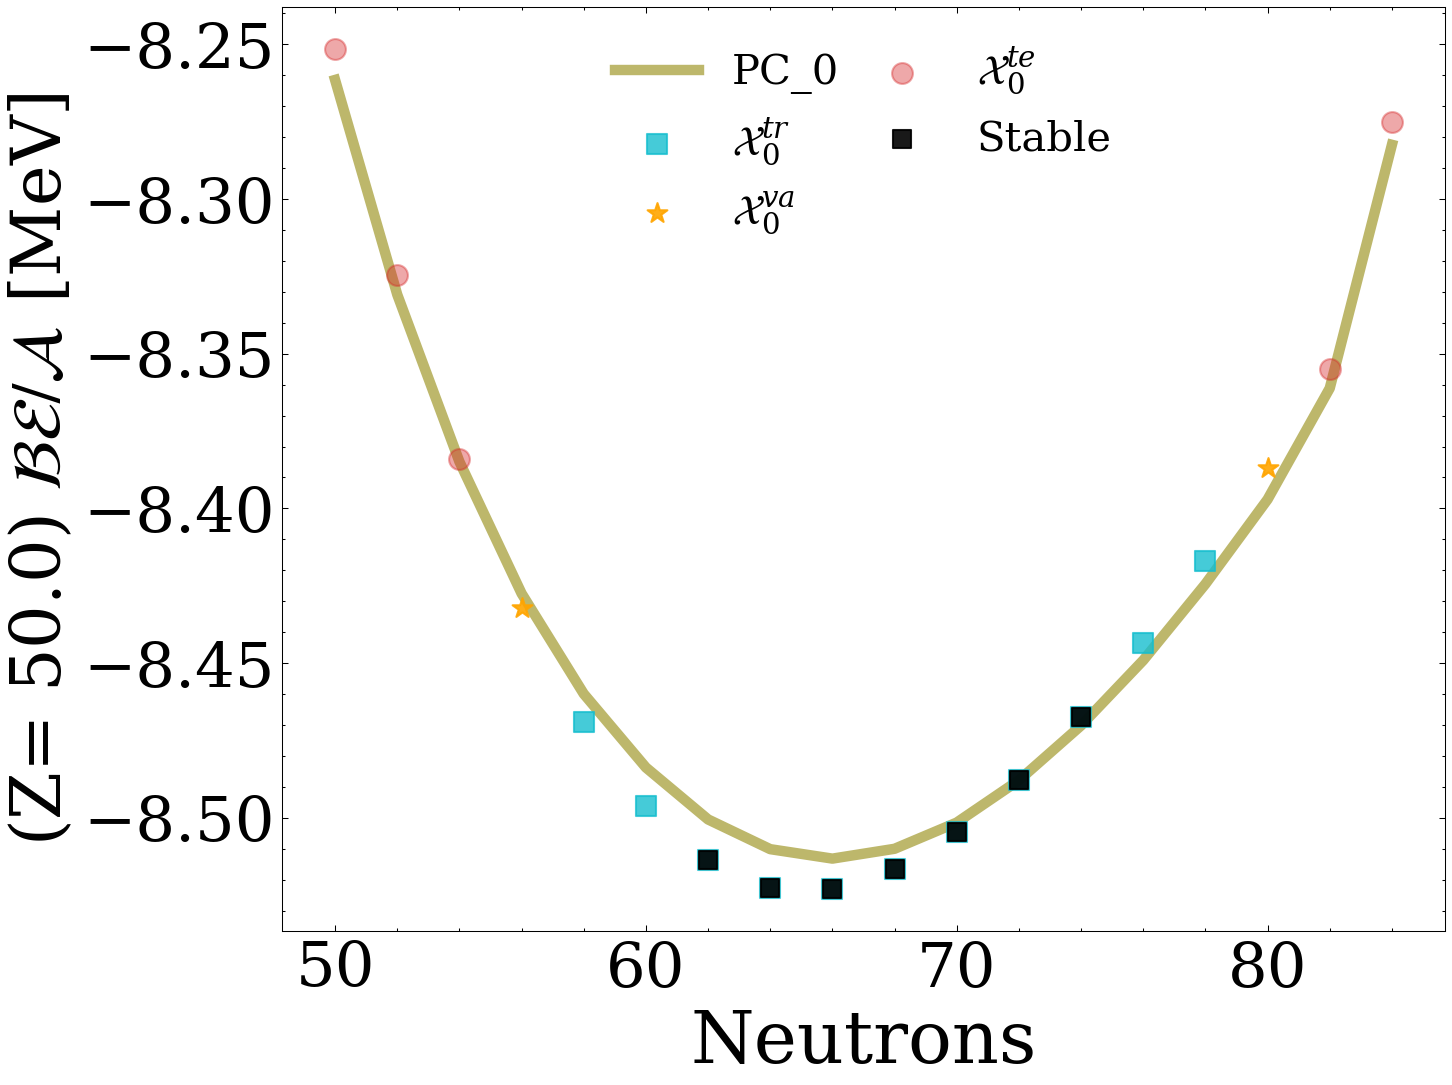

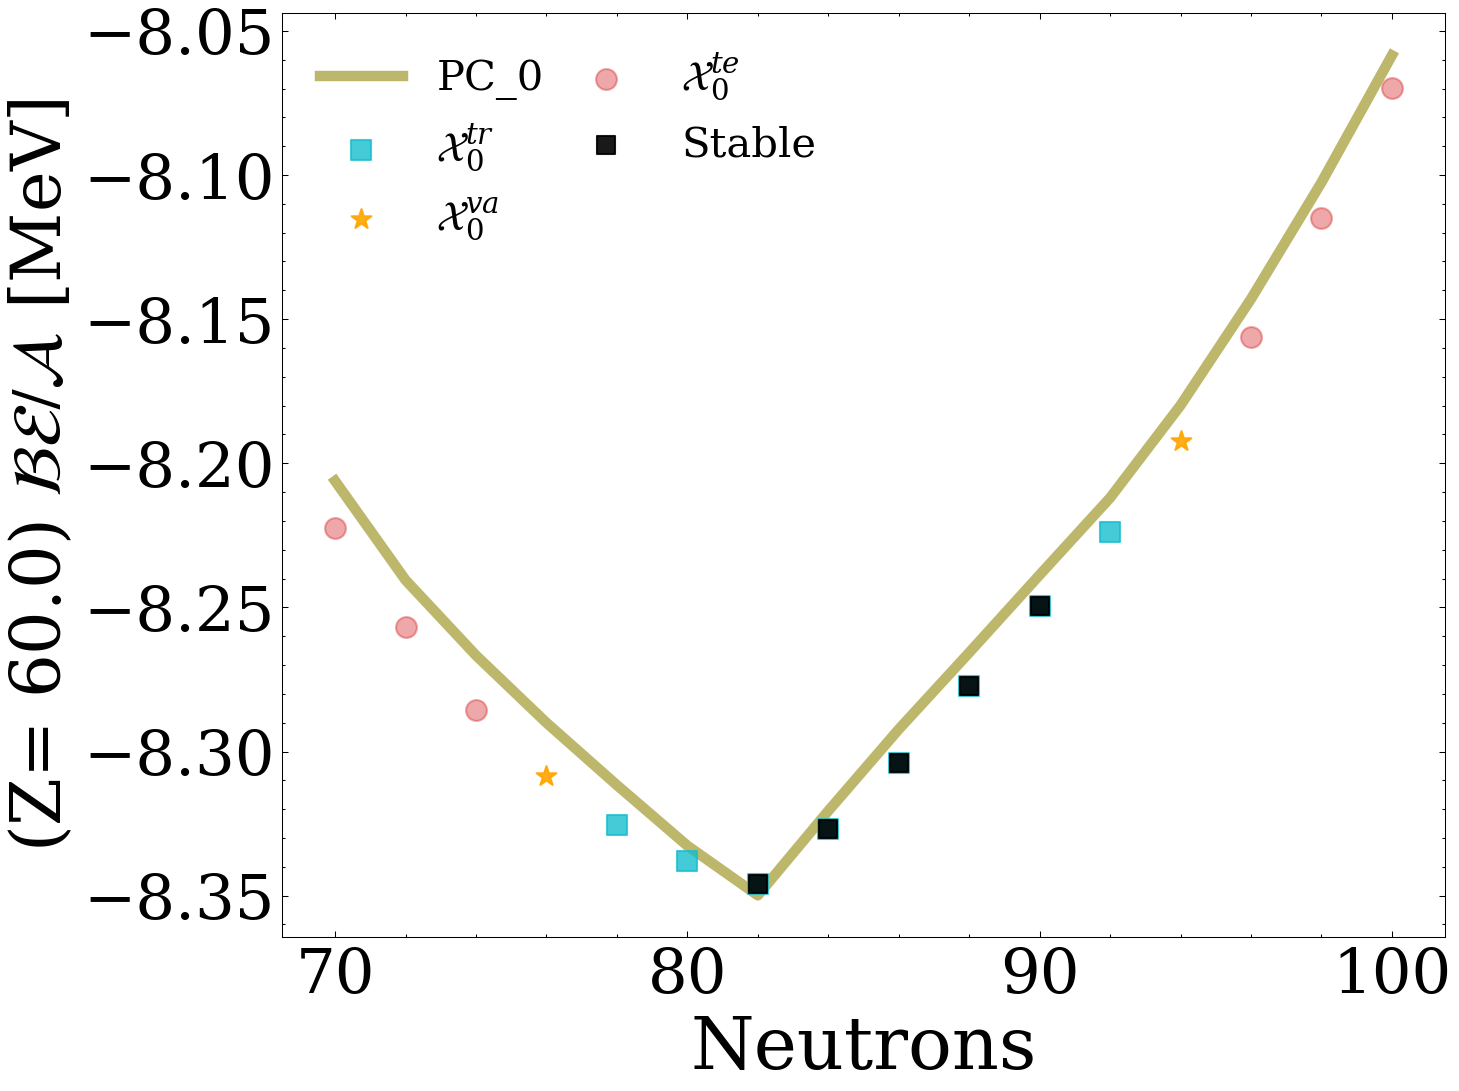

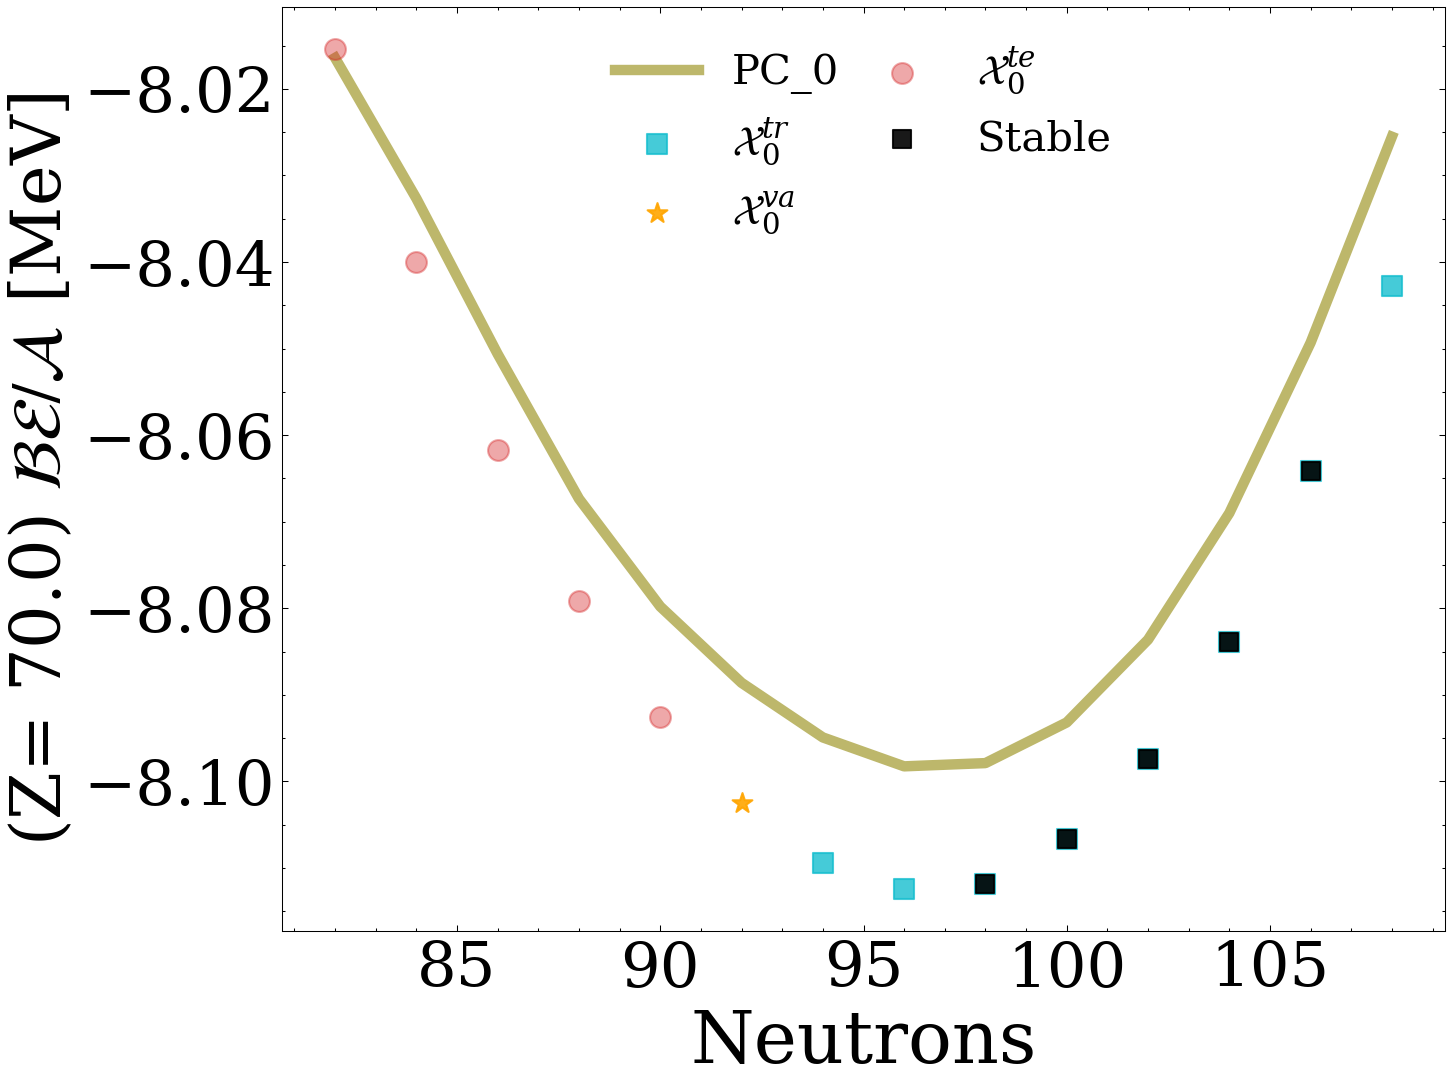

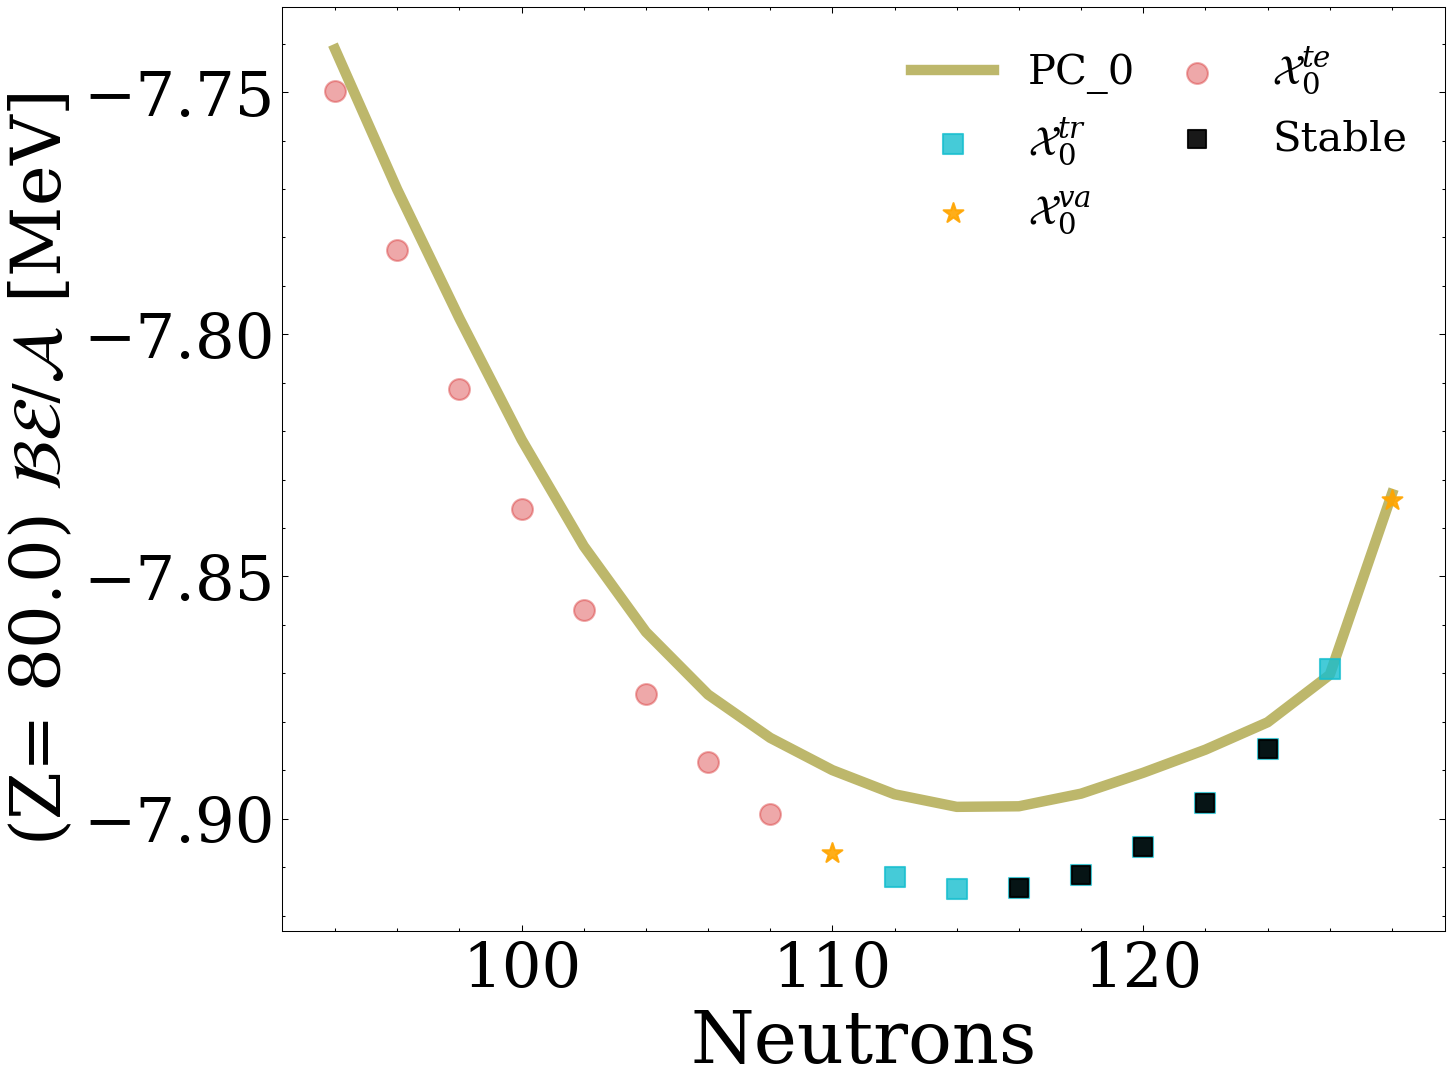

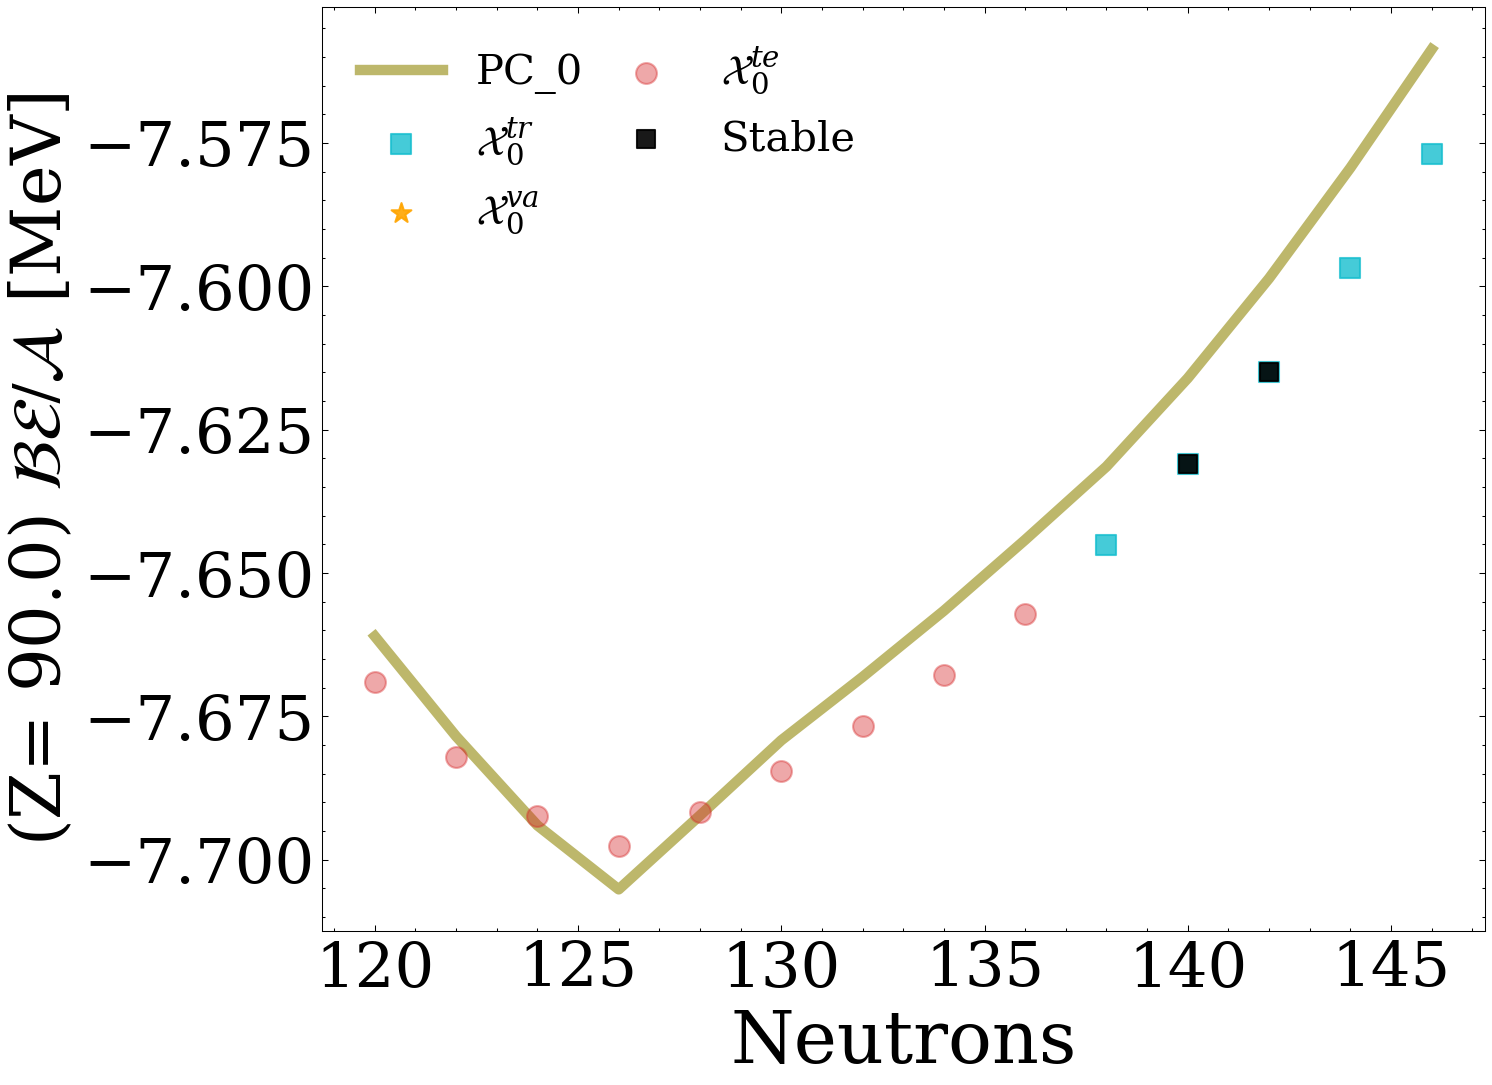

In [123]:
Selected_elements_list = ['Ca', 'Zn', 'Zr', 'Sn', 'Nd', 'Yb', 'Hg', 'Th']
dict_keys_mean = list(filtered_predictions_mean_mass_dict.keys())
dict_keys = list(filtered_models_output_mass_dict.keys())

i = 0
for key in dict_keys_mean:
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose
    plt.plot(filtered_predictions_mean_mass_dict[key][0]["N"], -filtered_predictions_mean_mass_dict[key][0]['PC_0']/filtered_predictions_mean_mass_dict[key][0]["A"] , color="darkkhaki", label='PC_0',linewidth=5)

    color_local= "khaki"

    # This gives you training predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][1]["N"], y = -filtered_models_output_mass_dict[dict_keys[i]][1]['truth']/filtered_models_output_mass_dict[dict_keys[i]][1]["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][2]["N"], y = -filtered_models_output_mass_dict[dict_keys[i]][2]['truth']/filtered_models_output_mass_dict[dict_keys[i]][2]["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][3]["N"], y = -filtered_models_output_mass_dict[dict_keys[i]][3]['truth']/filtered_models_output_mass_dict[dict_keys[i]][3]["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable predictions for these isotope
    ax.scatter(x = filtered_models_output_mass_dict[dict_keys[i]][4]["N"], y = -filtered_models_output_mass_dict[dict_keys[i]][4]['truth']/filtered_models_output_mass_dict[dict_keys[i]][4]["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {x[i]}) $ {{\\cal BE/A}}$ [MeV]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.savefig(f'Plots/Radii data/Mean model predictions - Mass/{Selected_elements_list[i]}')
    plt.show()

    i = i+1

In [231]:
np.abs(models_PC_mass['PC_3']).max()

0.2210995897781345

In [232]:
# First let's scale the principal components up so that it is comparable to the mean value
scaled_models_PC_mass = models_PC_mass.copy()
models_PC_mass_columns = list(models_PC_mass.columns)
for column in models_PC_mass_columns[4:]:
    scaled_models_PC_mass[column] = 2*scaled_models_PC_mass[column]

# print(scaled_models_PC_mass)
scaled_filtered_models_PC_mass_dict= filtered_models_output_dict_extraction(x, 'scaled_filtered_models_PC_mass_list_' , scaled_models_PC_mass,\
                                    train_coordinates_mass, validation_coordinates_mass, test_coordinates_radius, stable_coordinates)

#
for key in list(scaled_filtered_models_PC_mass_dict.keys()):
    for i, dataframe in enumerate(scaled_filtered_models_PC_mass_dict[key]):
        # Explicitly create a copy to avoid SettingWithCopyWarning
        dataframe_copy = dataframe.copy()

        # Perform the calculations on the copy
        dataframe_copy['PC_0'] = (dataframe['PC_0'] / dataframe['A']).copy()
        dataframe_copy.iloc[:, 4:] = dataframe_copy.iloc[:, 4:] + np.mean(dataframe_copy['PC_0'])

        # Assign the modified DataFrame back to the dictionary
        scaled_filtered_models_PC_mass_dict[key][i] = dataframe_copy

# Display the specific DataFrame from the dictionary
scaled_filtered_models_PC_mass_dict['scaled_filtered_models_PC_mass_list_30'][0]

,N,Z,A,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
103,28,30,58,8.374235,8.462129,8.828064,8.515314,8.285535,8.739186,8.725050,8.379707,8.954846,8.574717
104,30,30,60,8.541070,8.482122,8.832215,8.517762,8.338988,8.581242,8.617600,8.339049,8.611020,8.503164
105,32,30,62,8.643782,8.481744,8.854091,8.503797,8.387994,8.524907,8.576264,8.322192,8.601735,8.483732
106,34,30,64,8.703616,8.512303,8.814541,8.475356,8.503407,8.511636,8.563447,8.371344,8.461396,8.558533
107,36,30,66,8.733266,8.528342,8.791771,8.468182,8.552592,8.529027,8.539374,8.449748,8.445521,8.631852
108,38,30,68,8.742785,8.546620,8.771064,8.488035,8.616465,8.537832,8.454807,8.504911,8.345937,8.678101
109,40,30,70,8.737389,8.562295,8.737068,8.528181,8.689650,8.602962,8.453369,8.483648,8.230776,8.675142
110,42,30,72,8.697937,8.547457,8.758233,8.600885,8.679803,8.619299,8.470212,8.526066,8.435509,8.806244
111,44,30,74,8.648634,8.538590,8.747569,8.702006,8.702284,8.652159,8.553806,8.495542,8.528513,8.560282
112,46,30,76,8.591073,8.517553,8.741122,8.762688,8.726246,8.677017,8.645990,8.526554,8.591848,8.575058


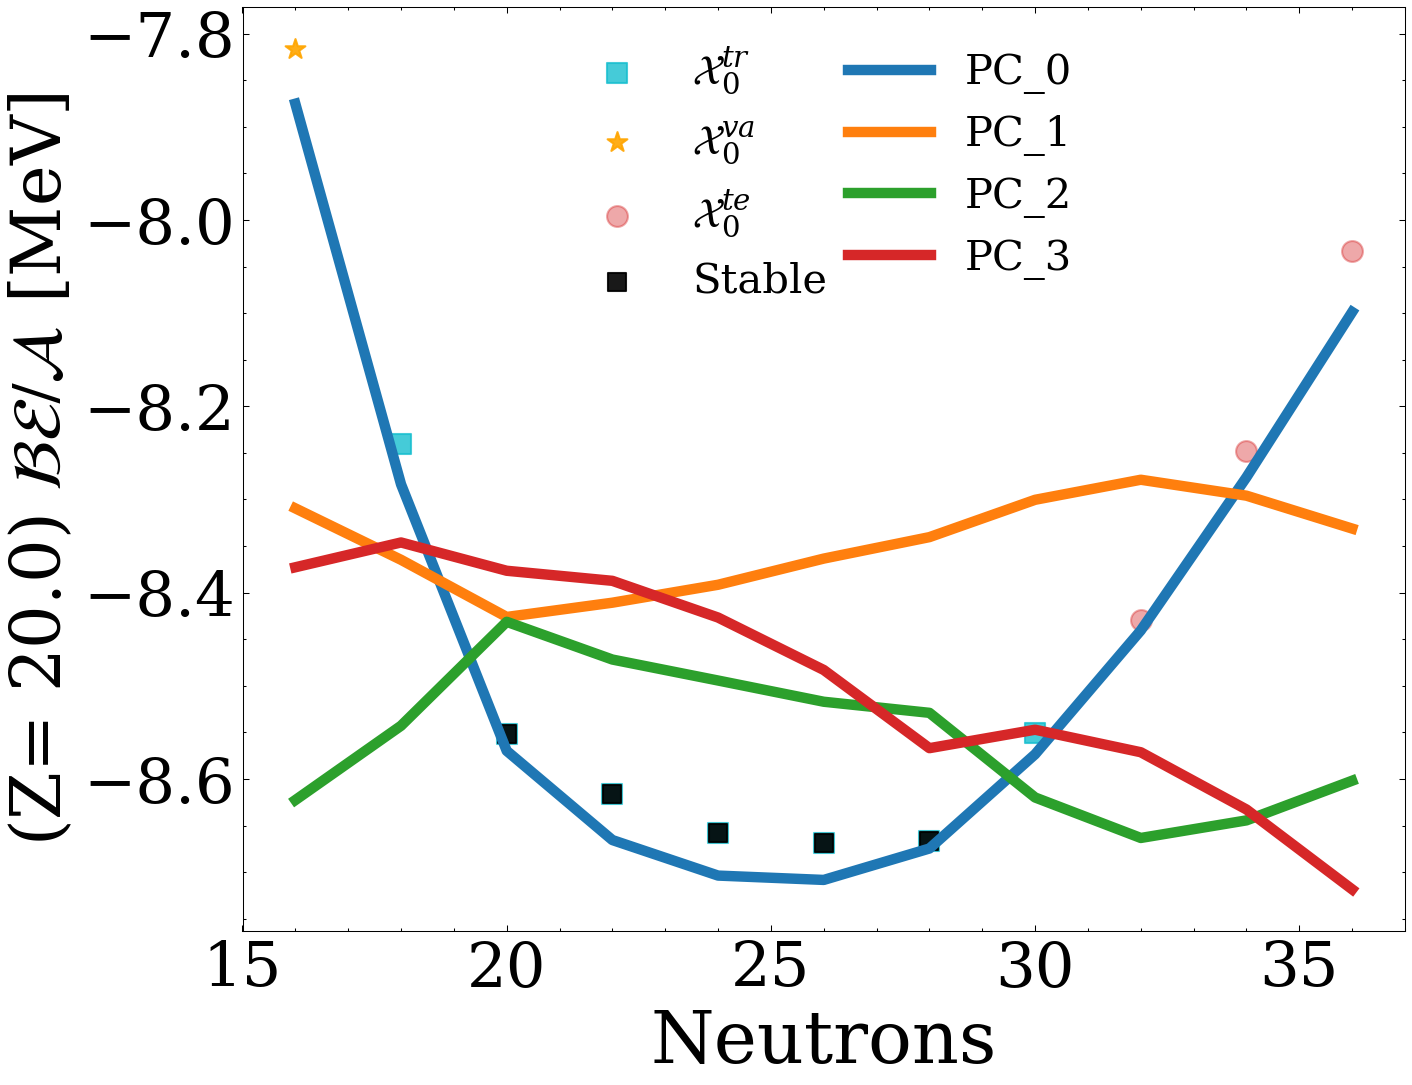

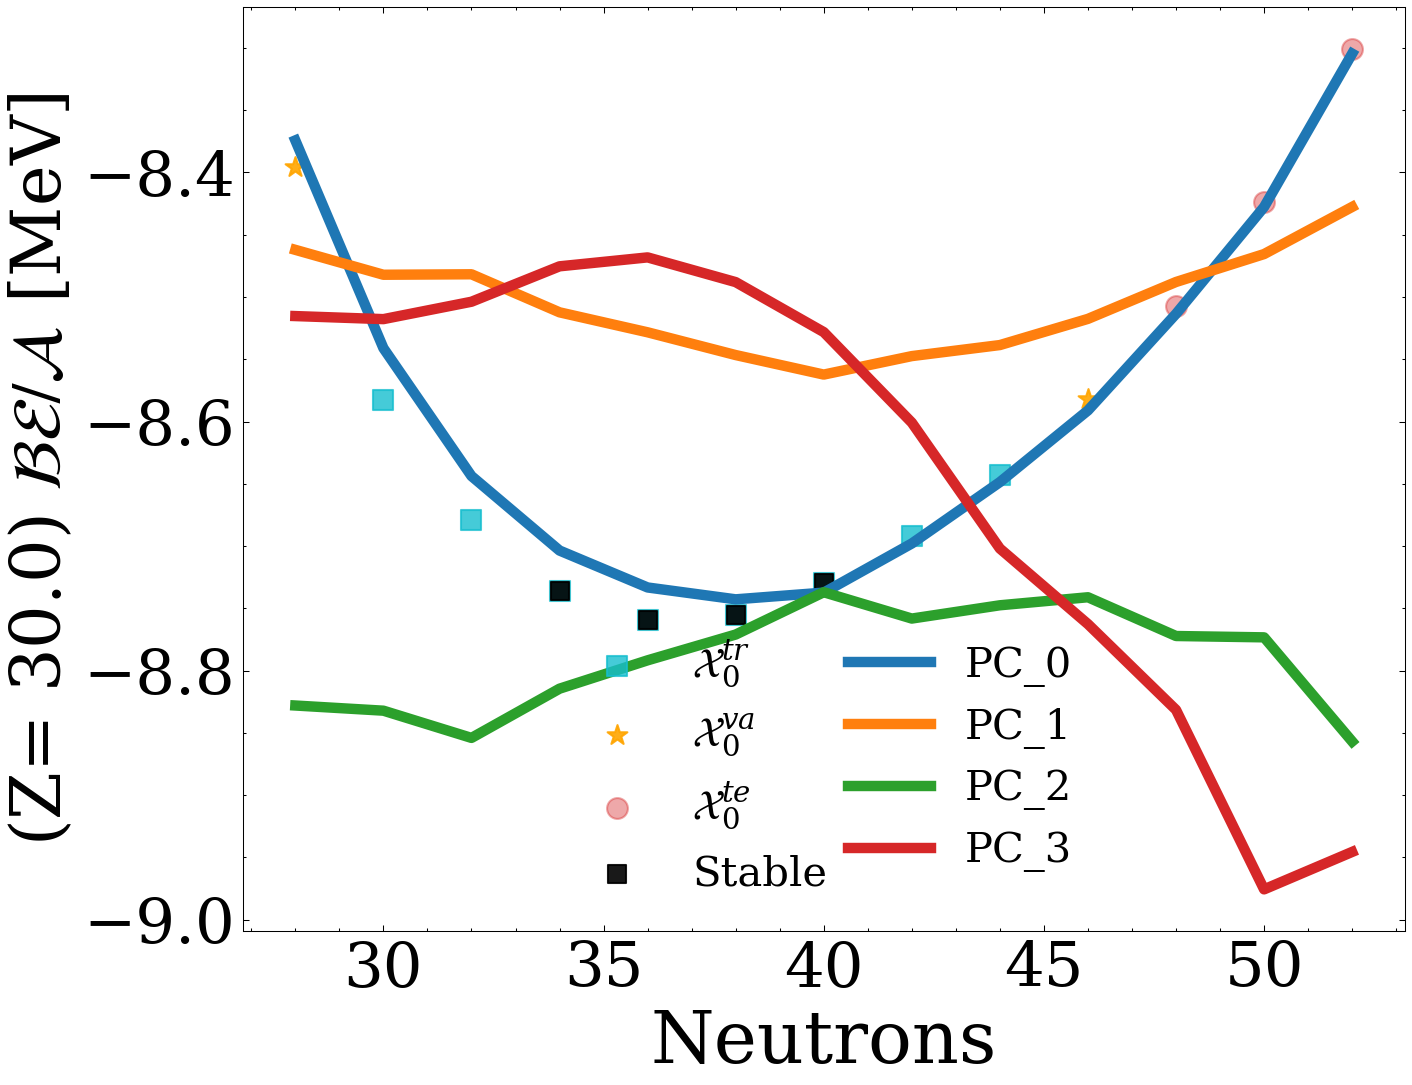

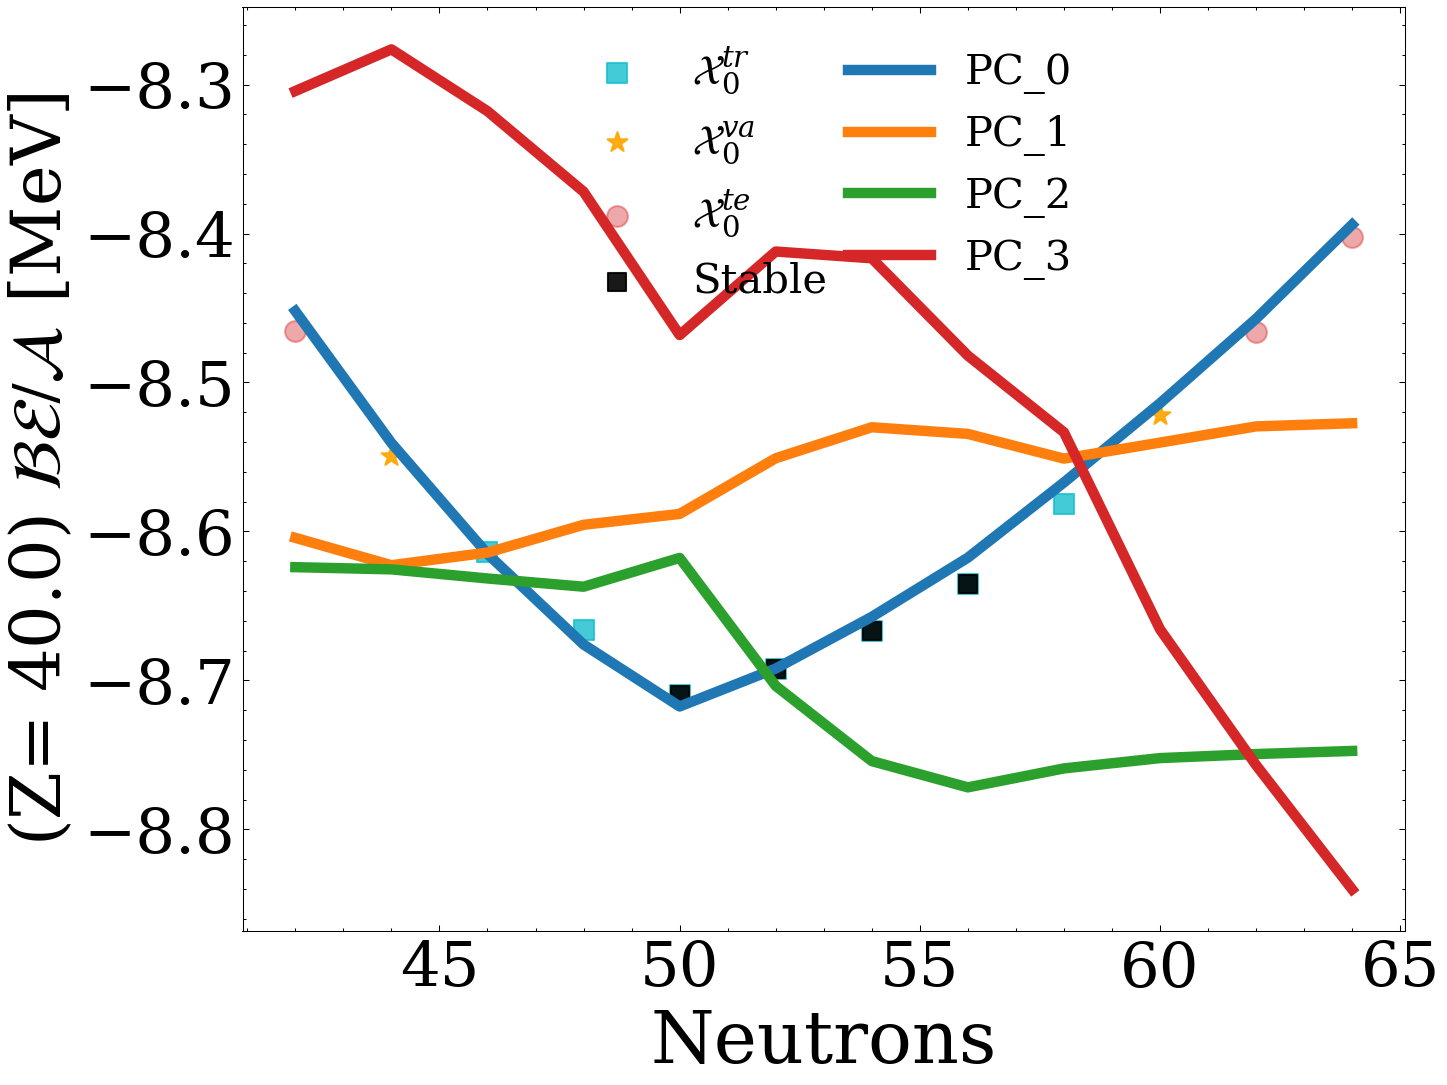

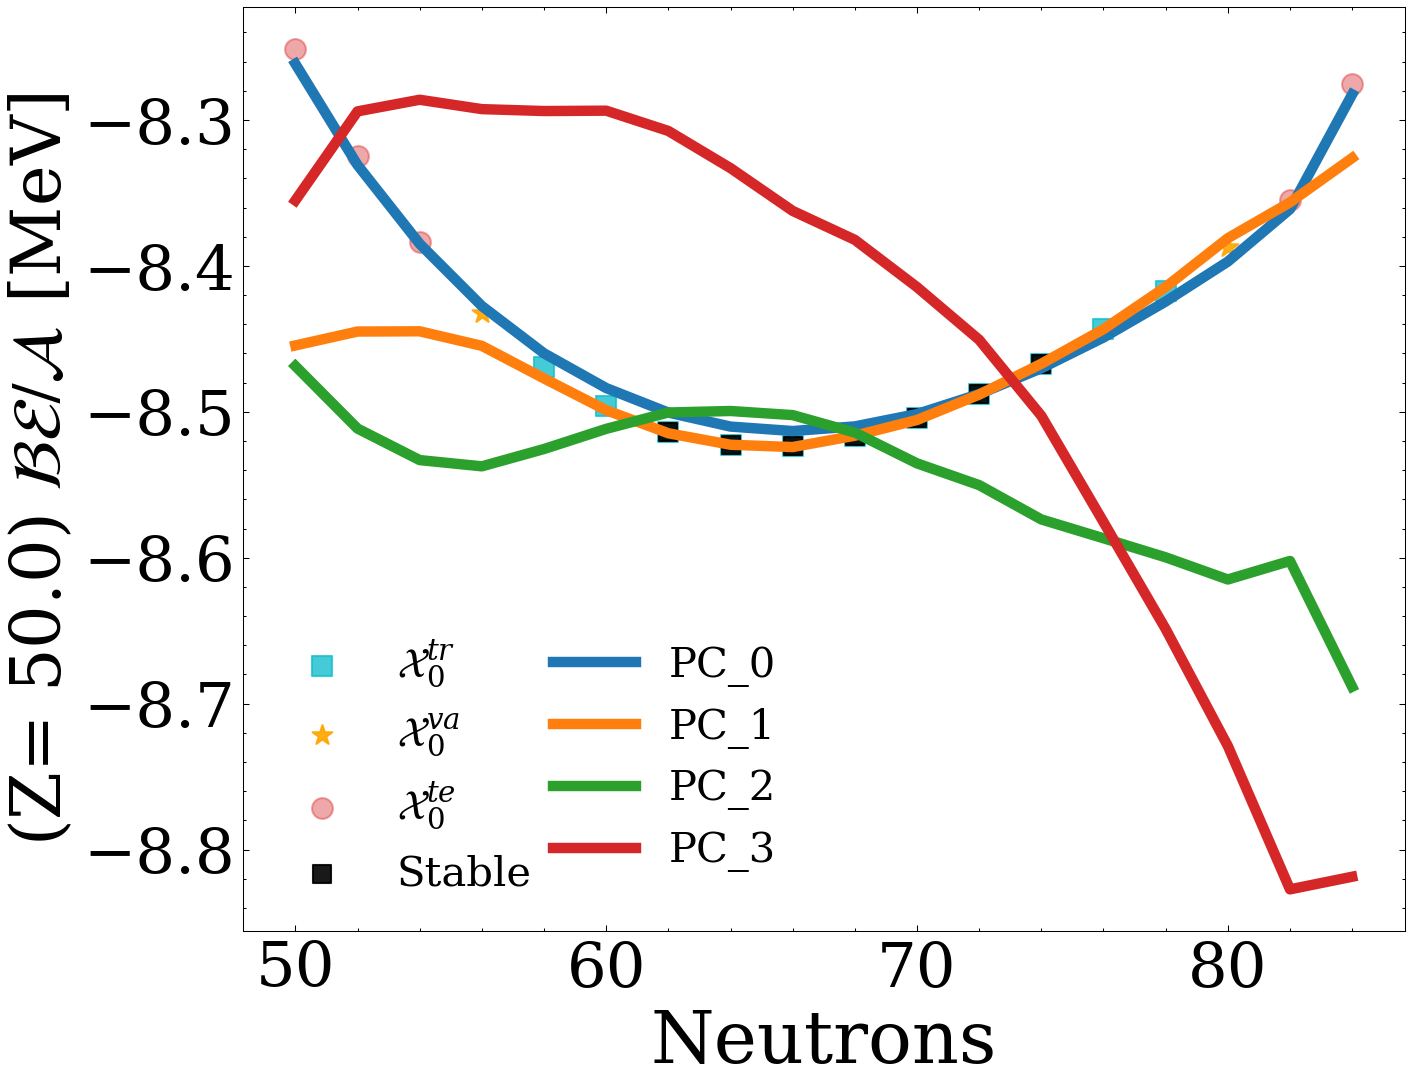

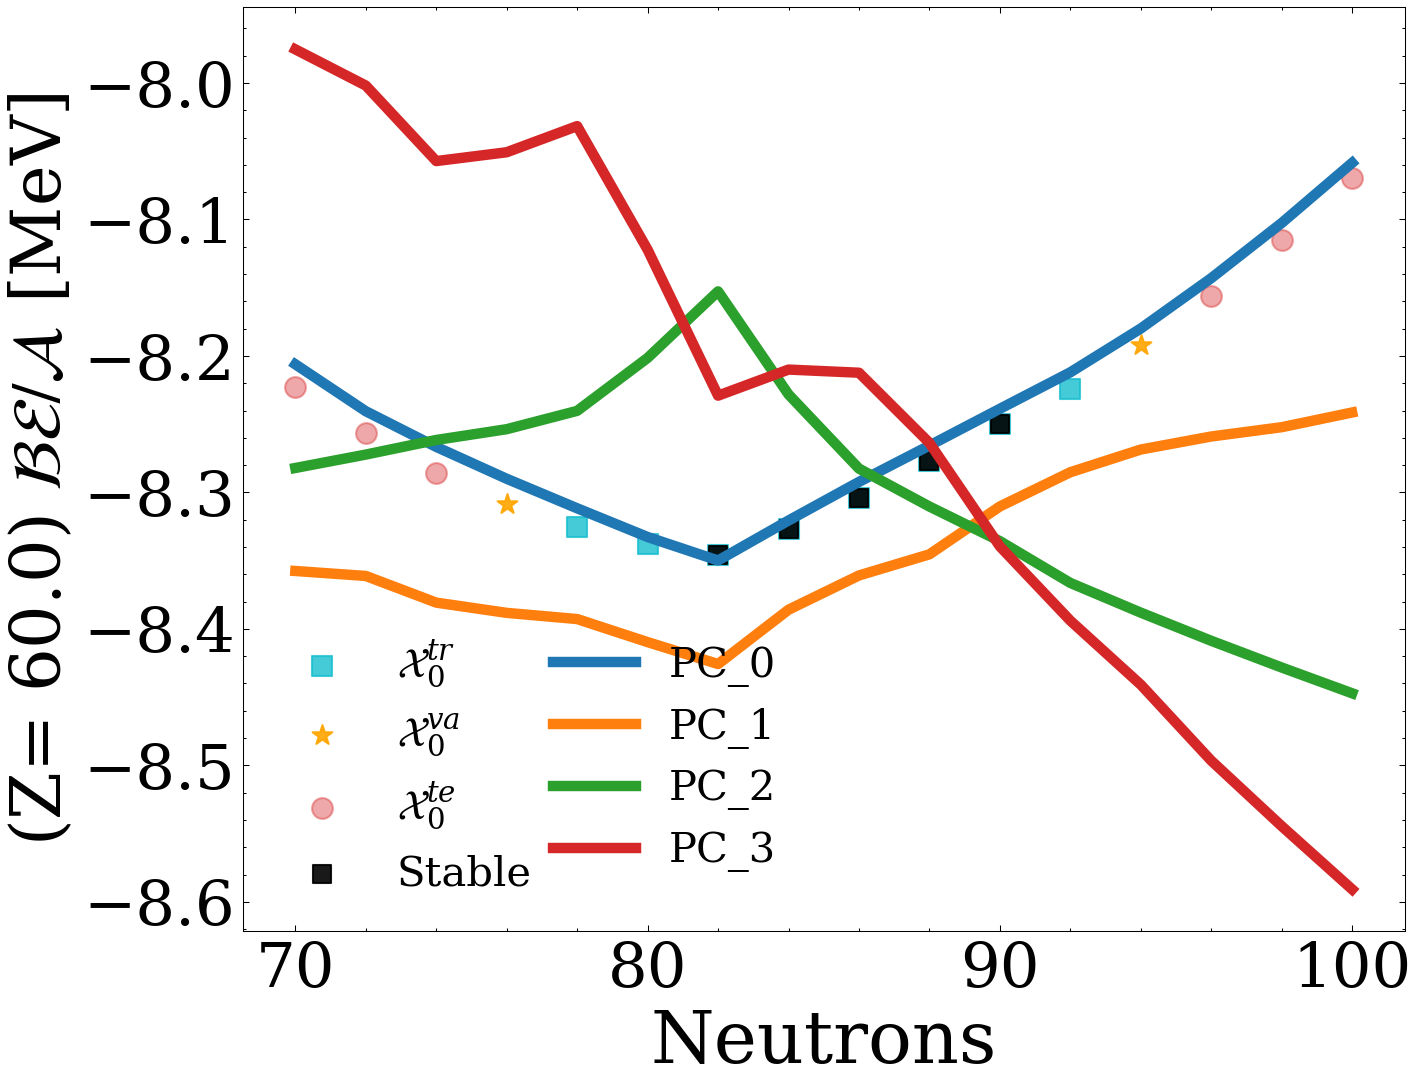

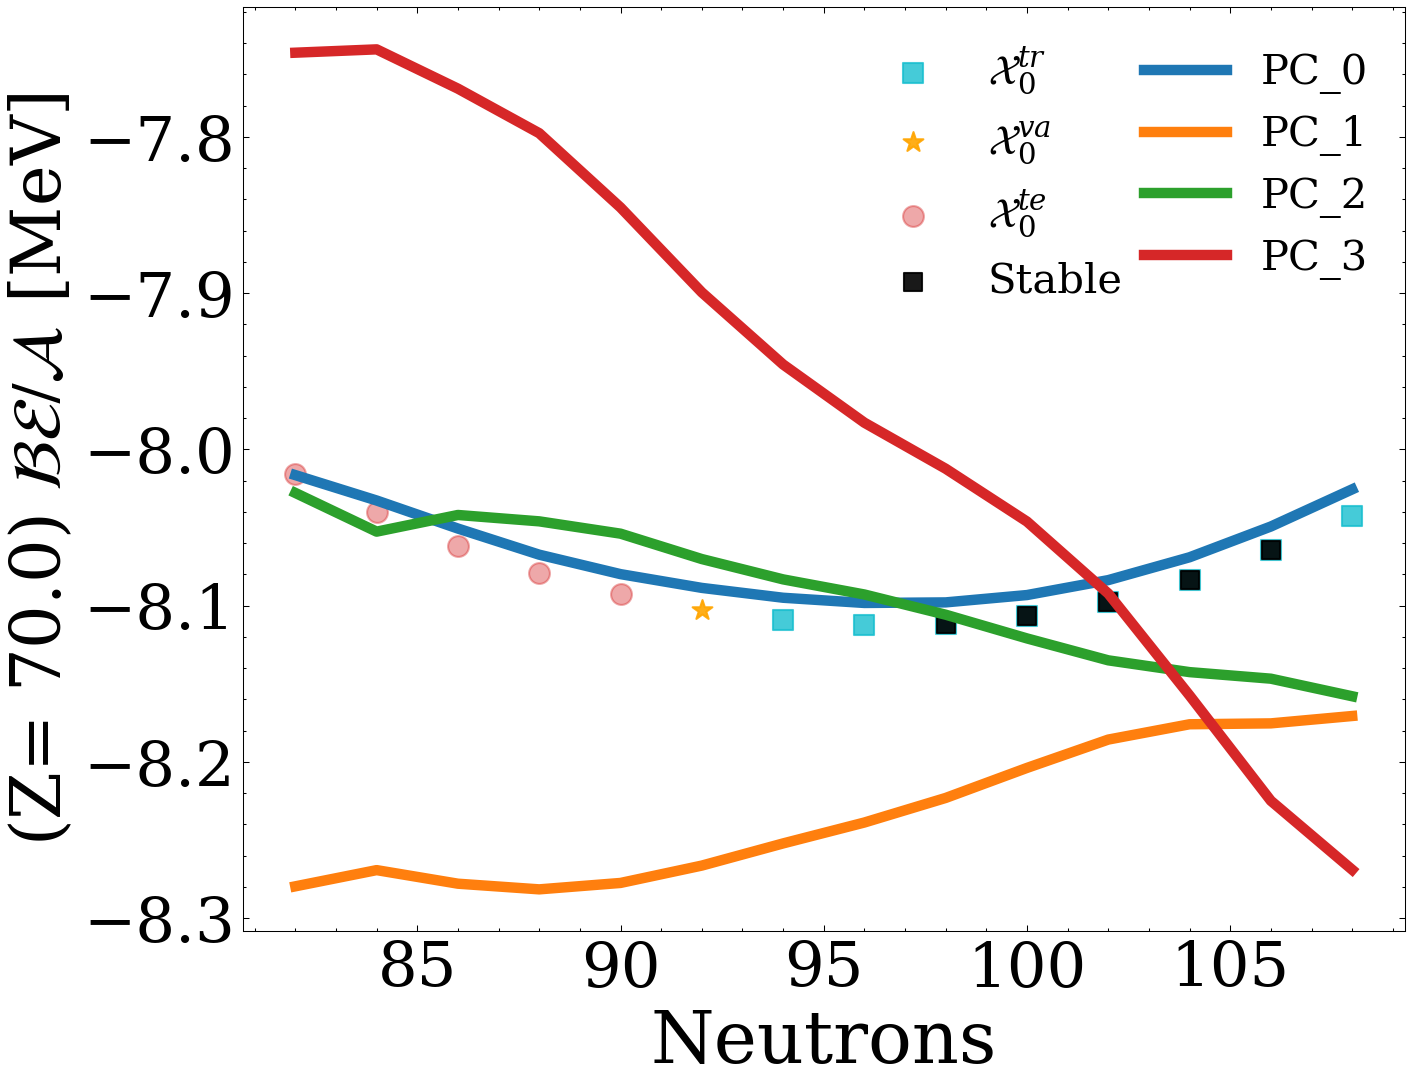

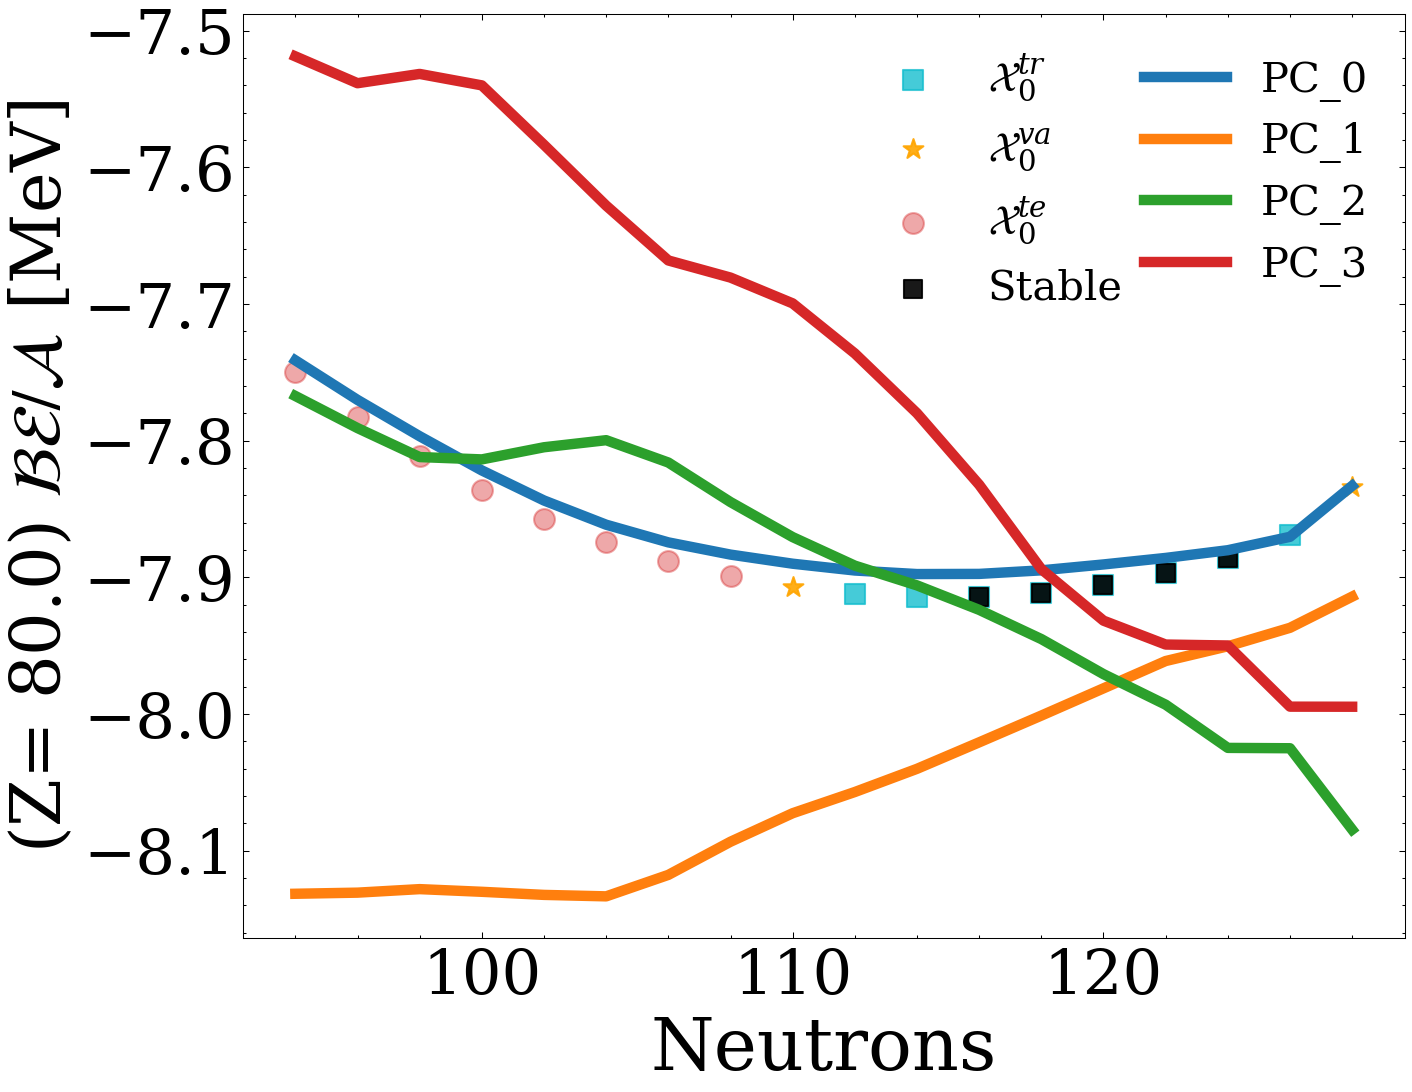

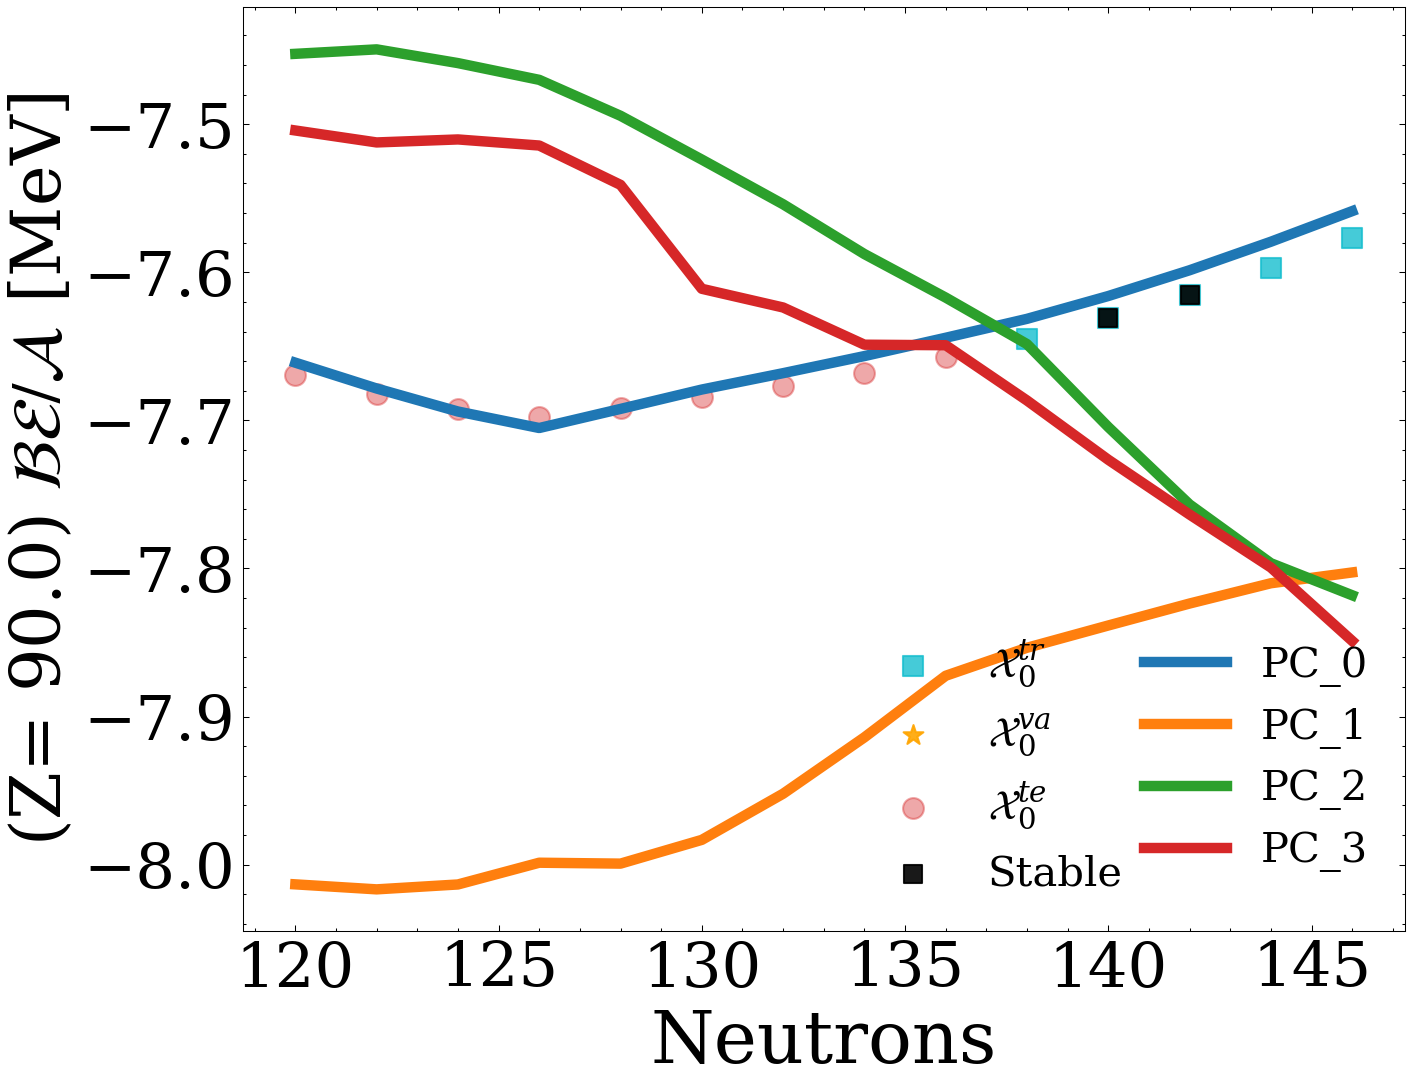

In [235]:
Selected_elements_list = ['Ca', 'Zn', 'Zr', 'Sn', 'Nd', 'Yb', 'Hg', 'Th']
for i in range(len(Selected_elements_list)):
    plot_filtered_real_data_dict_per_nucleon(Selected_elements_list, Selected_elements_list[i], filtered_models_output_mass_dict)
    index = Selected_elements_list.index(Selected_elements_list[i]) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(scaled_filtered_models_PC_mass_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = scaled_filtered_models_PC_mass_dict[dict_keys[index]][0][['PC_0', 'PC_1', 'PC_2', 'PC_3']] #This is the dataframe that we want to graph from
    for j in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[j]
        plt.plot(scaled_filtered_models_PC_mass_dict[dict_keys[index]][0]['N'], -filtered_models_something_else[column], color= colors[j], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {x[i]}) $ {{\\cal BE/A}}$ [MeV]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    plt.savefig(f'Plots/Radii data/PCs Visualizations - Mass/{Selected_elements_list[i]}')
    plt.show()

In [234]:
def models_RMSE_calculator(models_selected, models_output, models_output_train, models_output_validation, models_output_test):
    models_RMSE_train = []
    models_RMSE_validation = []
    models_RMSE_test = []
    models_RMSE_full = []

    for model in models_selected:
        residuals_train=models_output_train[model]-models_output_train['truth'].tolist()
        residuals_validation= models_output_validation[model]-models_output_validation['truth'].tolist()
        residuals_test = models_output_test[model]-models_output_test['truth'].tolist()
        residuals_full = models_output[model]-models_output['truth'].tolist()
    
        sigma_train=np.sqrt(np.sum(residuals_train**2) / len(residuals_train) )
        print(sigma_train)
        sigma_validation=np.sqrt(np.sum(residuals_validation**2) / len(residuals_validation) )
        sigma_test=np.sqrt(np.sum(residuals_test**2) / len(residuals_test) )
        sigma_full=np.sqrt(np.sum(residuals_full**2) / len(residuals_full) )

        models_RMSE_train.append(sigma_train)
        models_RMSE_validation.append(sigma_validation)
        models_RMSE_test.append(sigma_test)
        models_RMSE_full.append(sigma_full)
        
    return models_RMSE_train, models_RMSE_validation, models_RMSE_test, models_RMSE_full

In [99]:
models_RMSE_mass_train, models_RMSE_mass_validation, models_RMSE_mass_test, models_RMSE_mass_full = models_RMSE_calculator(models_selected,\
                                            models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test)

2.472792802479106
2.455281884636286
1.938838180103183
2.1801500173689488
4.914565172508562
3.0628825886565476
4.525943700862392
2.9669317050978328
1.4709855514095667
1.8241130073053045


32.767644685701846

In [77]:
super_params_train = super_params(model_predictions_mass_train, models_output_mass_train['truth'])
super_params_full = super_params(model_predictions_mass, models_output_mass['truth'])
super_params_test = super_params(model_predictions_mass_test, models_output_mass_test['truth'])

In [78]:
supermodel_residuals_mass_full_train, supermodel_residuals_mass_train_train, supermodel_residuals_mass_validation_train, supermodel_residuals_mass_test_train = residuals_calculator(super_params_train, model_predictions_mass_list, models_output_mass_list)
supermodel_residuals_mass_full_full, supermodel_residuals_mass_train_full, supermodel_residuals_mass_validation_full, supermodel_residuals_mass_test_full = residuals_calculator(super_params_full, model_predictions_mass_list, models_output_mass_list)
supermodel_residuals_mass_full_test, supermodel_residuals_mass_train_test, supermodel_residuals_mass_validation_test, supermodel_residuals_mass_test_test = residuals_calculator(super_params_test, model_predictions_mass_list, models_output_mass_list)

In [79]:
supermodel_sigma_mass_train_train=np.sqrt(np.sum(supermodel_residuals_mass_train_train**2) / len(supermodel_residuals_mass_train_train) )
supermodel_sigma_mass_validation_train=np.sqrt(np.sum(supermodel_residuals_mass_validation_train**2) / len(supermodel_residuals_mass_validation_train) )
supermodel_sigma_mass_test_train=np.sqrt(np.sum(supermodel_residuals_mass_test_train**2) / len(supermodel_residuals_mass_test_train) )
supermodel_sigma_mass_full_train=np.sqrt(np.sum(supermodel_residuals_mass_full_train**2) / len(supermodel_residuals_mass_full_train) )

supermodel_sigma_mass_train_test=np.sqrt(np.sum(supermodel_residuals_mass_train_test**2) / len(supermodel_residuals_mass_train_test) )
supermodel_sigma_mass_validation_test=np.sqrt(np.sum(supermodel_residuals_mass_validation_test**2) / len(supermodel_residuals_mass_validation_test) )
supermodel_sigma_mass_test_test=np.sqrt(np.sum(supermodel_residuals_mass_test_test**2) / len(supermodel_residuals_mass_test_test) )
supermodel_sigma_mass_full_test=np.sqrt(np.sum(supermodel_residuals_mass_full_test**2) / len(supermodel_residuals_mass_full_test) )

supermodel_sigma_mass_train_full=np.sqrt(np.sum(supermodel_residuals_mass_train_full**2) / len(supermodel_residuals_mass_train_full) )
supermodel_sigma_mass_validation_full=np.sqrt(np.sum(supermodel_residuals_mass_validation_full**2) / len(supermodel_residuals_mass_validation_full) )
supermodel_sigma_mass_test_full=np.sqrt(np.sum(supermodel_residuals_mass_test_full**2) / len(supermodel_residuals_mass_test_full) )
supermodel_sigma_mass_full_full=np.sqrt(np.sum(supermodel_residuals_mass_full_full**2) / len(supermodel_residuals_mass_full_full) )

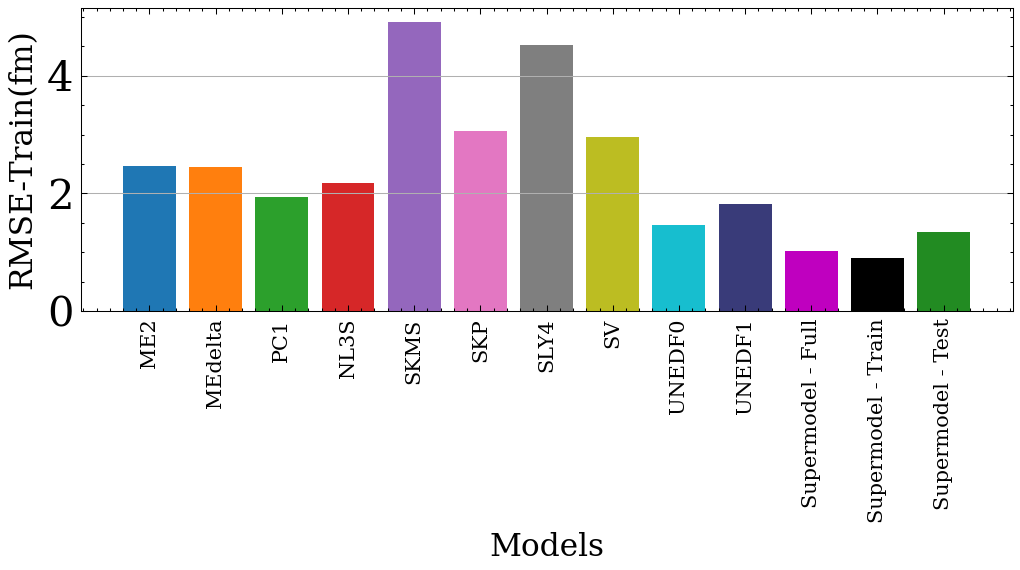

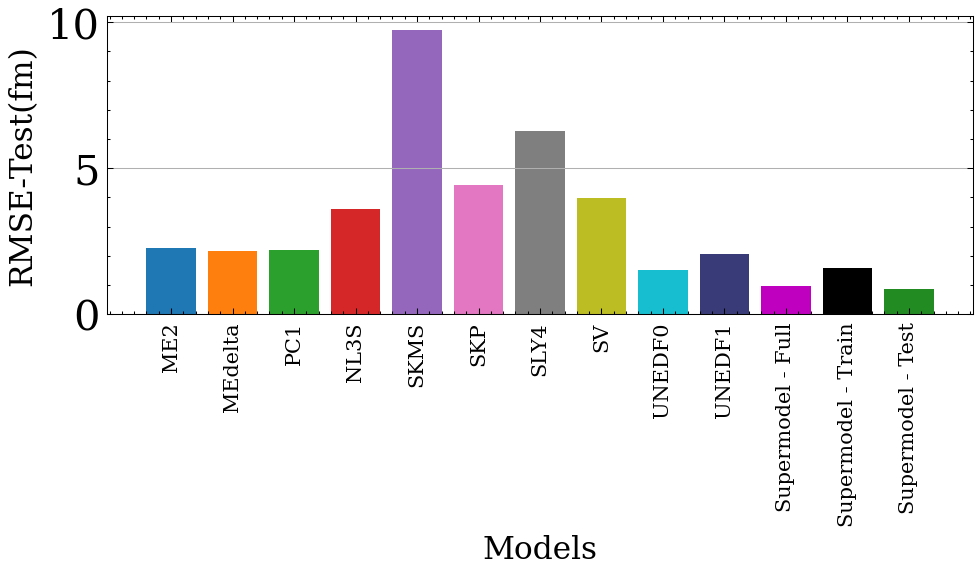

In [100]:
y_max = 0.05

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_mass_train[i], color = colors[i])
    i+=1
plt.bar('Supermodel - Full', supermodel_sigma_mass_train_full, color = 'm')
plt.bar('Supermodel - Train', supermodel_sigma_mass_train_train, color = 'k')
plt.bar('Supermodel - Test', supermodel_sigma_mass_train_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Train(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data/Models RMSE/Models RMSE training region.png')
plt.show()

#############################
# test region ###############

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_mass_test[i], color = colors[i])
    i+=1
plt.bar('Supermodel - Full', supermodel_sigma_mass_test_full, color = 'm')
plt.bar('Supermodel - Train', supermodel_sigma_mass_test_train, color = 'k')
plt.bar('Supermodel - Test', supermodel_sigma_mass_test_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Test(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data/Models RMSE/Models RMSE testing region.png')
plt.show()


In [82]:
models_RMSE_mass_train

[0.01931708622849939,
 0.029609031232698646,
 0.022370160300192028,
 0.024016264448990233,
 0.01996366501473007,
 0.030891263091515388,
 0.02450755115161652,
 0.021632737590482665,
 0.02129322676458181,
 0.022634024572869678]